# iToF / Structured-Light Fusion Pipeline 

Calibration and depth fusion for a combined indirect Time-of-Flight (iToF) and Structured Light (SL) approach.
Based on:
- **Microsoft-Paper** – Godbaz et al. 2025 (Microsoft): dot calibration (4.1), 1-D dot trails, consistency error, active brightness trail (4.2)
- **Agresti** – Agresti & Zanuttigh, ECCV 2018: maximum likelihood depth fusion (eq. 16/17)


All heavy lifting lives in `dot_calibration.py`, `calibrate.py`
and `approaches.py`. So this notebook only orchestrates and visualizes.

In [1]:
from dot_calibration import DotCalibration
import approaches
import calibrate
import os
import numpy as np
from pathlib import Path
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
import matplotlib.pyplot as plt

dotCal = DotCalibration()

# ── Camera / data selection / presets in calibrate.py
CAMERA = "SchmersalReal"          # "OnSemi" (Simulation) or "Schmersal" (Simulation) or "SchmersalReal" (First real measurement)
cfg     = calibrate.CAMERAS[CAMERA]
sl_cal  = cfg["sl_cal"]
tof_cal = cfg["tof_cal"]
K       = cfg["K"]          
CAL_BLOB_PARAMS = cfg["cal_blob"]
TOF_SAMPLE      = cfg.get("tof_sample")   # how to read ToF depth at a dot (see calibrate.CAMERAS)

K_inv = np.linalg.inv(K)
fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

SUBPIXEL_MODE = "GPR"      # paper: LoG + GPR ("geometricCenter" as fallback)
TRACK_IN_TX_SPACE = False  # True: re-track in transmitter space (Godbaz 4.1)
BASELINE_OUTLIER_SIGMA = 3.0  # Godbaz: outlier-ray removal before the final Baseline fit
MIN_TRACK_POINTS = 3       # low-confidence invalidation: min distances per dot line
TRAIL_Z_MIN = 0.35          # trails run from here to infinity [m] (Godbaz: ~30 cm)

calibration_figures = []   # list of (name, fig)
print("Setup complete.")

Setup complete.


## Statistical Outlier Removal (CloudCompare-style)

Filters every point cloud the notebook loads, exactly the way CloudCompare's *SOR
filter* does: a point is rejected when the mean distance to its `SOR_K` nearest
neighbours exceeds `mean + SOR_NSIGMA · std` of that quantity over the whole cloud.
Defaults are CloudCompare's own — **6 points, nSigma 1.00**.

The `.pcd` files on disk are never modified. Each load is served from a temporary
copy in which the rejected points are NaN'd; the copy is deleted straight after it
has been read. `SOR_ENABLED = False` restores the raw behaviour, and every cache
file carries `SOR_TAG`, so filtered and unfiltered results can coexist.
`PCD_CAP = [z_min, z_max]` (metres, `None` = off) additionally cuts every cloud to
that depth window before the SOR statistics are computed; the cap is part of `SOR_TAG`.


In [2]:
# ── Statistical Outlier Removal (CloudCompare's SOR filter) ──────────────────
# For every point: the mean distance to its SOR_K nearest neighbours. A point is
# rejected when that mean exceeds   mean(all) + SOR_NSIGMA · std(all)   — exactly
# what CloudCompare does, and SOR_K = 6 / SOR_NSIGMA = 1.00 are its defaults.
#
# The PCDs on disk are NEVER touched. Every load is served from a temporary copy
# in which the rejected points are NaN'd, and that copy is deleted again as soon
# as it has been read (the source tree is ~93 GB — caching it would mirror it).
# Points are NaN'd rather than dropped because the clouds are organised (640×480)
# and load_tof_pcd only builds points_map / depth_map / intensity_map while
# WIDTH·HEIGHT == POINTS.
#
# Geometry only: grayValue is left alone, so the active-brightness EXRs and
# approach 3's dot detection see exactly the same image as before. Only the
# iToF depth that approaches 1 and 2 consume is filtered.
import atexit
import itertools
import shutil
import sys
import tempfile
import time
from scipy.spatial import cKDTree

SOR_ENABLED   = True    # False → everything runs on the raw clouds, as before
SOR_K         = 6       # CloudCompare "points to use for mean distance estimation"
SOR_NSIGMA    = 1.00    # CloudCompare "standard deviation multiplier"
SOR_KEEP_TEMP = False   # True → keep the filtered clouds until the kernel exits
SOR_VERBOSE   = False   # True → one line per filtered file
PCD_CAP       = [0.0,2.0]    # None → no cap | [z_min, z_max] in metres, e.g. [0.0, 2.0]
                        # points outside are NaN'd before the SOR statistics (works with SOR off too)

# Goes into every cache filename, so filtered and unfiltered results can never be
# mixed up and can be compared by flipping SOR_ENABLED.
SOR_TAG = ((f"_sor{SOR_K}-{SOR_NSIGMA:.2f}" if SOR_ENABLED else "")
           + (f"_cap{PCD_CAP[0]:.2f}-{PCD_CAP[1]:.2f}" if PCD_CAP is not None else ""))

# The repo's PCD header parser, reused read-only (removePCDoutliers.py is not modified).
_repo_root = Path.cwd().parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))
import removePCDoutliers as _rpo

SOR_PROBE_PCD = Path("/home/julian/Documents/Calibrations/"
                     "RauschmessungiToF10x10450375050step/ToFPCD/0.45m/Nr0.pcd")


def _sor_cleanup():
    # Only the process that made the directory may remove it — a forked sweep
    # worker exiting must not delete the tree the parent is still using.
    if os.getpid() == _SOR_OWNER_PID:
        shutil.rmtree(SOR_TMPDIR, ignore_errors=True)


if "SOR_TMPDIR" not in globals() or not Path(SOR_TMPDIR).is_dir():
    SOR_TMPDIR = Path(tempfile.mkdtemp(prefix="sor_pcd_"))
    _SOR_OWNER_PID = os.getpid()
    atexit.register(_sor_cleanup)

_sor_counter = itertools.count()
_sor_warned = set()


def _sor_warn_once(src, why):
    if why not in _sor_warned:
        _sor_warned.add(why)
        print(f"  [sor] not filtered ({why}) — e.g. {Path(src).name}; passing the source through")


def sor_keep_mask(xyz, k=None, nsigma=None, z_range=None, sor=True):
    """CloudCompare's statistical outlier removal.

    `xyz` is (N, 3) in metres. Returns (keep, threshold, n_valid): a boolean mask
    over the rows, the rejection threshold on the mean-kNN distance [m], and how
    many points carried a ToF return at all.

    Pixels without a return are excluded from the neighbour statistics and come
    back as not-kept: the sensor writes them as exactly (0, 0, 0), and a pile of
    ~10^5 coincident points at the origin would otherwise have zero neighbour
    distance and pull the mean far below the real surface spacing. The gate is
    the same one load_tof_pcd applies (DotCalibration.VALID_Z_RANGE), so no point
    is dropped here that the pipeline would have used — unless PCD_CAP narrows
    that gate on purpose. `sor=False` applies only this gate (no kNN step).
    """
    k = int(SOR_K if k is None else k)
    nsigma = float(SOR_NSIGMA if nsigma is None else nsigma)
    if z_range is None:
        z_lo, z_hi = DotCalibration.VALID_Z_RANGE
        if PCD_CAP is not None:
            z_lo, z_hi = max(z_lo, PCD_CAP[0]), min(z_hi, PCD_CAP[1])
    else:
        z_lo, z_hi = z_range

    xyz = np.asarray(xyz, dtype=np.float64)
    valid = (np.isfinite(xyz).all(axis=1)
             & np.any(xyz != 0.0, axis=1)
             & (xyz[:, 2] >= z_lo) & (xyz[:, 2] <= z_hi))
    keep = np.zeros(len(xyz), dtype=bool)
    idx = np.flatnonzero(valid)
    if not sor or idx.size <= k + 1:      # cap only / too few points to say anything                      # too few points to say anything
        keep[idx] = True
        return keep, float("inf"), int(idx.size)

    pts = xyz[idx]
    # k + 1 because the query point matches itself at distance 0; dropping that
    # column leaves exactly k neighbours, as CloudCompare counts them.
    d, _ = cKDTree(pts).query(pts, k=k + 1, workers=1)   # workers=1: the sweep
    mean_d = d[:, 1:].mean(axis=1)                       # already runs 5 processes
    thr = float(mean_d.mean() + nsigma * mean_d.std())
    keep[idx] = mean_d <= thr
    return keep, thr, int(idx.size)


def sor_pcd_to_temp(src, unit_scale=0.001):
    """Write a SOR-filtered copy of `src` into SOR_TMPDIR and return its path.

    `src` is only ever read. The header is copied through byte for byte — the
    point count does not change, so WIDTH/HEIGHT stay correct and the copy is
    still an organised cloud. Returns `src` itself when the file cannot be
    filtered in place (ascii, binary_compressed, no xyz).
    """
    src = Path(src)
    raw = src.read_bytes()
    try:
        hdr, header_len, _ = _rpo.parse_header(raw)
        dtype = _rpo.build_dtype(hdr)[0]
    except Exception as exc:                                    # noqa: BLE001
        _sor_warn_once(src, f"header not parsable: {type(exc).__name__}")
        return src
    if hdr.get("DATA", "").split()[0].lower() != "binary":
        _sor_warn_once(src, f"DATA {hdr.get('DATA')!r}, only binary is filtered in place")
        return src
    if not all(f in dtype.names for f in ("x", "y", "z")):
        _sor_warn_once(src, "no x/y/z fields")
        return src

    npts = int(hdr["POINTS"]) if "POINTS" in hdr else int(hdr["WIDTH"]) * int(hdr["HEIGHT"])
    arr = np.frombuffer(raw, dtype=dtype, count=npts, offset=header_len).copy()
    xyz = np.stack([arr["x"], arr["y"], arr["z"]], axis=1).astype(np.float64) * unit_scale

    keep, thr, n_valid = sor_keep_mask(xyz, sor=SOR_ENABLED)
    drop = ~keep
    for f in ("x", "y", "z", "rad", "distZ"):      # geometry only — grayValue stays
        if f in dtype.names and np.issubdtype(dtype[f], np.floating):
            arr[f][drop] = np.nan

    dst = SOR_TMPDIR / f"{src.stem}_p{os.getpid()}_{next(_sor_counter)}.pcd"
    with open(dst, "wb") as fh:
        fh.write(raw[:header_len])
        fh.write(arr.tobytes())
    if SOR_VERBOSE:
        n_kept = int(keep.sum())
        print(f"  [sor] {src.name}: {n_valid} valid → {n_kept} kept "
              f"({100.0 * (n_valid - n_kept) / max(n_valid, 1):.1f}% rejected, "
              f"thr {thr * 1e3:.2f} mm)")
    return dst


# ── The hook: every PCD the notebook reads goes through load_tof_pcd ─────────
# the calibration back-projection (cell 7), the Step A spot check, and
# approaches.common_setup inside the sweep. Patching this one method covers all
# of them, and the fork-based worker pool inherits the patch.
if "_sor_orig_load_tof_pcd" not in globals():
    _sor_orig_load_tof_pcd = DotCalibration.load_tof_pcd


def _sor_load_tof_pcd(self, pcd_path, *args, **kwargs):
    if not SOR_ENABLED and PCD_CAP is None:
        return _sor_orig_load_tof_pcd(self, pcd_path, *args, **kwargs)
    unit_scale = kwargs.get("unit_scale", args[0] if args else 0.001)
    tmp = Path(sor_pcd_to_temp(pcd_path, unit_scale=unit_scale))
    try:
        return _sor_orig_load_tof_pcd(self, str(tmp), *args, **kwargs)
    finally:
        if not SOR_KEEP_TEMP and tmp != Path(pcd_path):
            tmp.unlink(missing_ok=True)


DotCalibration.load_tof_pcd = _sor_load_tof_pcd

# ── Probe one frame, so the aggressiveness of the setting is visible up front ─
print("cap: " + (f"{PCD_CAP[0]:.2f}–{PCD_CAP[1]:.2f} m (z)" if PCD_CAP is not None else "off"))
if not SOR_ENABLED:
    print("SOR disabled — the pipeline reads the " + ("capped" if PCD_CAP is not None else "raw") + " clouds.")
elif not SOR_PROBE_PCD.exists():
    print(f"SOR active ({SOR_K} pts, {SOR_NSIGMA:.2f} σ) — probe not found: {SOR_PROBE_PCD}")
else:
    _raw = SOR_PROBE_PCD.read_bytes()
    _hdr, _hl, _ = _rpo.parse_header(_raw)
    _dty = _rpo.build_dtype(_hdr)[0]
    _n = int(_hdr["POINTS"])
    _a = np.frombuffer(_raw, dtype=_dty, count=_n, offset=_hl)
    _xyz = np.stack([_a["x"], _a["y"], _a["z"]], axis=1).astype(np.float64) * 0.001
    _t0 = time.time()
    _keep, _thr, _nv = sor_keep_mask(_xyz)
    _el = time.time() - _t0
    _tmp = Path(sor_pcd_to_temp(SOR_PROBE_PCD))
    _kept = int(_keep.sum())
    print(f"SOR active: {SOR_K} neighbours, nSigma = {SOR_NSIGMA:.2f}   (cache tag '{SOR_TAG}')")
    print(f"  probe {SOR_PROBE_PCD.parent.name}/{SOR_PROBE_PCD.name}: {_n} points, "
          f"{_nv} with a ToF return")
    print(f"  kept {_kept}, rejected {_nv - _kept} "
          f"({100.0 * (_nv - _kept) / max(_nv, 1):.1f}% of the valid points)")
    print(f"  max mean-{SOR_K}NN distance = {_thr * 1e3:.3f} mm   |   {_el:.2f} s per cloud")
    print(f"  source {SOR_PROBE_PCD.stat().st_size / 1e6:.1f} MB (untouched)  →  "
          f"temp {_tmp.stat().st_size / 1e6:.1f} MB")
    _tmp.unlink(missing_ok=True)
print(f"temp clouds: {SOR_TMPDIR}  (deleted when the kernel exits)")


cap: 0.00–2.00 m (z)
SOR active: 6 neighbours, nSigma = 1.00   (cache tag '_sor6-1.00_cap0.00-2.00')
  probe 0.45m/Nr0.pcd: 307200 points, 295870 with a ToF return
  kept 288710, rejected 7160 (2.4% of the valid points)
  max mean-6NN distance = 8.043 mm   |   0.43 s per cloud
  source 14.7 MB (untouched)  →  temp 14.7 MB
temp clouds: /tmp/sor_pcd_2364wbzs  (deleted when the kernel exits)


## Calibration Steps 1–2: Dot Detection, Subpixel Localisation & Tracking

LoG blob detection on each calibration SL image, followed by GPR
(Godbaz 4.1: LoG finds the area near the peak, a Gaussian-process model of the intensity
map is searched for the subpixel location). No fixed grid is assumed.

Stable IDs are then assigned by tracking each dot across the calibration distances with
a nearest-neighbor search; dots may enter/leave FOV between distances.

Calibration distances: [0.402, 0.439, 0.486, 0.545, 0.621, 0.72, 0.857, 1.059, 1.385, 2.0]
  Processing Pos0.exr …


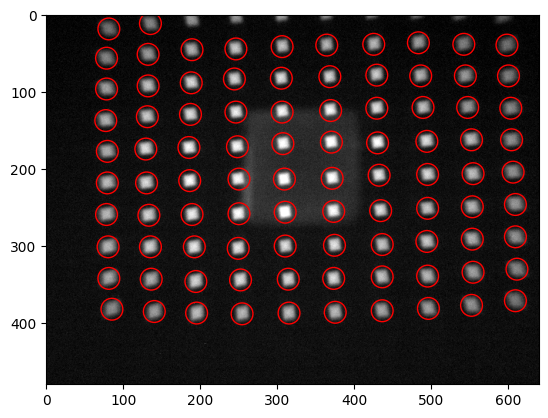

  Processing Pos1.exr …


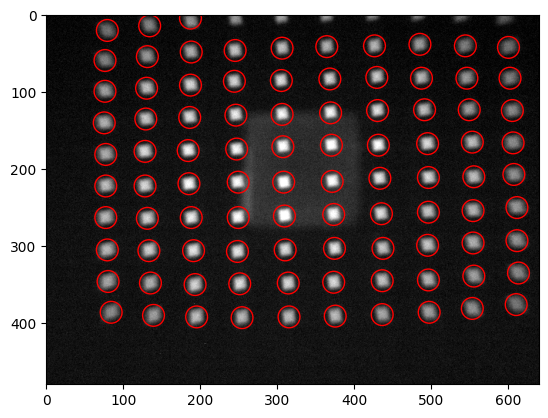

  Processing Pos2.exr …


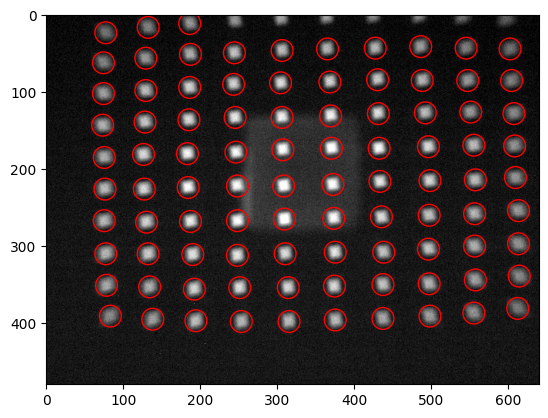

  Processing Pos3.exr …


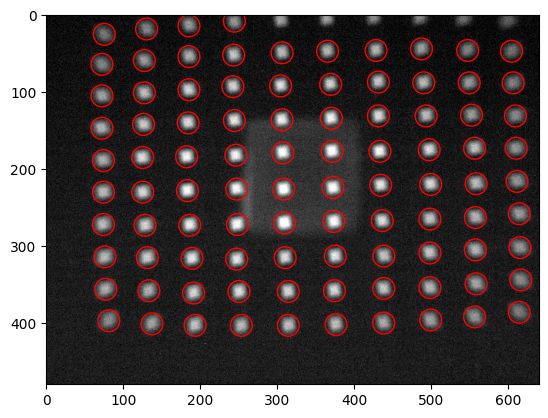

  Processing Pos4.exr …


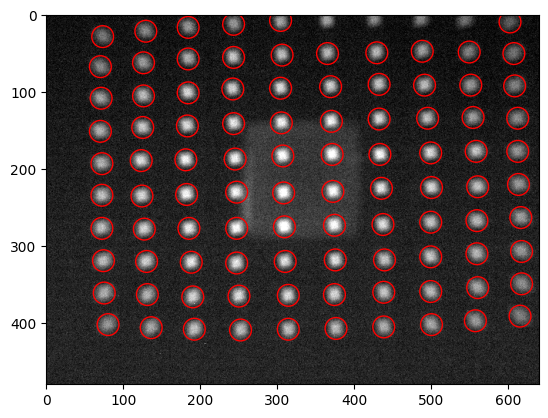

  Processing Pos5.exr …


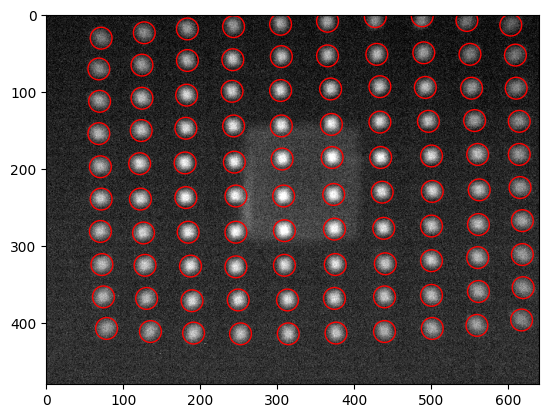

  Processing Pos6.exr …


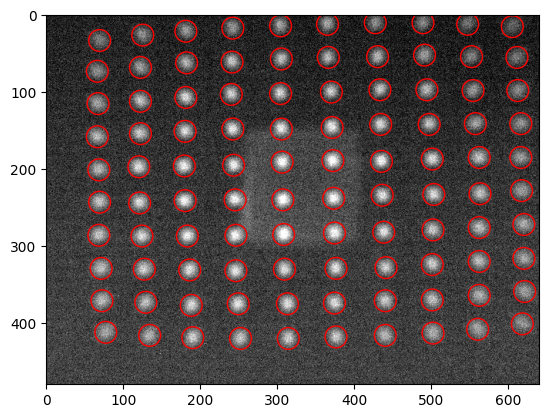

  Processing Pos7.exr …


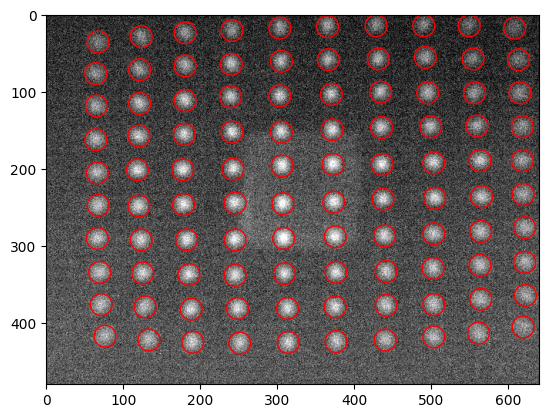

  Processing Pos8.exr …


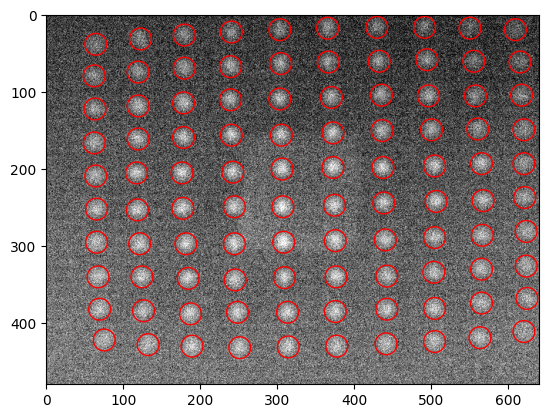

  Processing Pos9.exr …


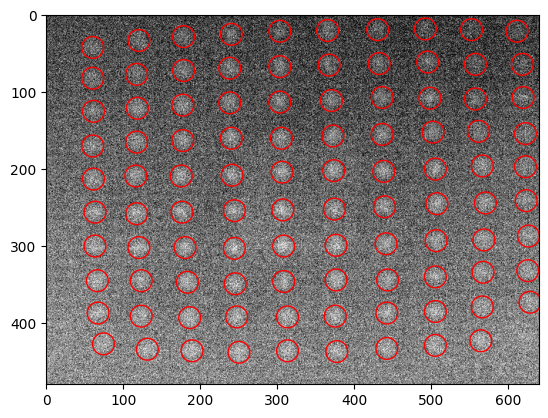


Dots per distance (raw, no grid enforced): [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]
Tracked roster size: 100 dots
IDed dots per distance: [92, 93, 93, 94, 96, 100, 100, 100, 100, 99]


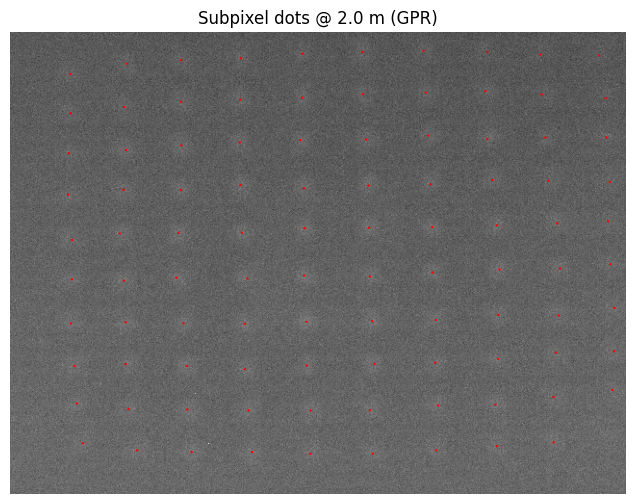

In [3]:
# Collect calibration PCD paths sorted by distance. Pattern and any excluded
# frames come from calibrate.CAMERAS (e.g. Pos9 @3.8 m unwraps wrongly).
EXCLUDE = set(cfg.get("exclude", ()))
pcd_files = sorted(
    (p for p in tof_cal.glob(cfg.get("pcd_glob", "ToF_*m.pcd"))
     if p.stem not in EXCLUDE),
    key=lambda p: calibrate.distance_for(cfg, dotCal, p) or 999.0
)

tof_paths = [str(p) for p in pcd_files]
cal_dists = [calibrate.distance_for(cfg, dotCal, p) for p in tof_paths]
print(f"Calibration distances: {cal_dists}")

# ── Steps 1+2: LoG blob detection + GPR subpixel refinement ─────────────
subpixel_list_unordered = []
for tof_p in tof_paths:
    sl_p = calibrate.find_sl_image(sl_cal, Path(tof_p).name)
    print(f"  Processing {Path(sl_p).name} …")
    blobs, image = dotCal.detect_blobs(str(sl_p), visualize=True, **CAL_BLOB_PARAMS)
    _, subpixels = dotCal.detect_subpixel_locations(blobs, image, mode=SUBPIXEL_MODE)
    subpixel_list_unordered.append(subpixels)

print(f"\nDots per distance (raw, no grid enforced): "
      f"{[len(s) for s in subpixel_list_unordered]}")

# ── Step 2b: cross-distance NN tracking -> stable IDs (Godbaz 4.1) ────────
subpixel_list = dotCal.track_dots_across_distances(
    subpixel_list_unordered, ref_idx=0, threshold_factor=0.5)

n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
print(f"Tracked roster size: {n_dots} dots")
print(f"IDed dots per distance: {[len(s) for s in subpixel_list]}")

# ── Visualize last calibration distance ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image, cmap="gray", alpha=0.8)
for d in subpixel_list[-1]:
    ax.add_patch(plt.Circle((d["x"], d["y"]), 0.5,
                            edgecolor="red", facecolor="none", linewidth=1))
ax.set_title(f"Subpixel dots @ {cal_dists[-1]} m ({SUBPIXEL_MODE})")
ax.axis("off")
calibration_figures.append(("step1_2_subpixel_dots", fig))
plt.show()

## Calibration Step 2c: X/Y Travel-Mode Detection

Detecting if the baseline travels in the x or y direction. (Simulatin: X, Real: Y)

With *TRACK_IN_TX_SPACE = True* the dots are re-tracked in the (approximately parallax
invariant) transmitter space using the derived baseline guess, as in the paper.

In [4]:
mode_info = dotCal.detect_travel_mode(subpixel_list, cal_dists, K)
mode = mode_info["mode"]
B_guess_vec = mode_info["B_guess_vec"]
print(f"Travel mode: {mode}")
print(f"du/dw = {mode_info['du_dw']:.2f} px·m,  dv/dw = {mode_info['dv_dw']:.2f} px·m")
print(f"Signed baseline estimate along {mode}: {mode_info['B_axis_est']*100:.3f} cm")
print(f"Signed baseline estimate along z: {mode_info['B_z_est']*100:.3f} cm "
      f"(from {mode_info['n_fit']} dots)")
print(f"B_guess_vec = {B_guess_vec}")

if TRACK_IN_TX_SPACE:
    coords_list = dotCal.tx_space_coords(
        subpixel_list_unordered, tof_paths, K=K, baseline_guess=B_guess_vec)
    subpixel_list = dotCal.track_dots_across_distances(
        subpixel_list_unordered, ref_idx=0, threshold_factor=0.5,
        coords_list=coords_list, travel_mode=mode)
    n_dots = max(int(d["id"]) for spx in subpixel_list for d in spx) + 1
    print(f"Re-tracked in transmitter space: roster {n_dots} dots")

Travel mode: y
du/dw = 0.14 px·m,  dv/dw = -18.92 px·m
Signed baseline estimate along y: -3.760 cm
Signed baseline estimate along z: 3.139 cm (from 100 dots)
B_guess_vec = [ 0.00083253 -0.03760109  0.0313942 ]


## Calibration Step 3: 3-D Back-Projection

For each detected dot at pixel (u, v), the iToF measurement is sampled
bilinearly to obtain the 3-D point U_ij in camera coordinates; U_tx = U − B_guess.

U shape:    (100, 10, 3)     (n_dots × n_dist × xyz)
U_tx shape: (100, 10, 3)  (shifted by B_guess = [ 0.00083253 -0.03760109  0.0313942 ])


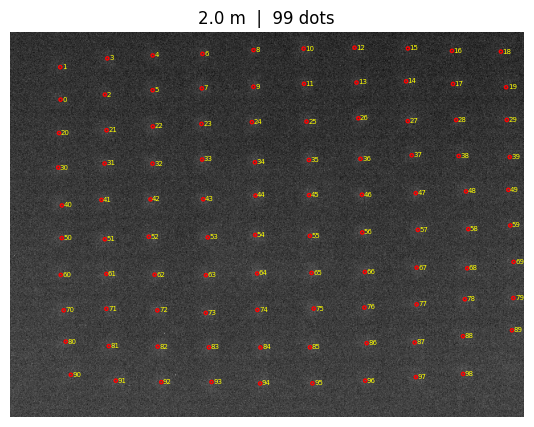

In [5]:
U, U_tx = dotCal.backproject_calibration_dots(
    subpixel_list, tof_paths, K=K,
    pcd_depth_mode="radial",
    baseline_guess=B_guess_vec,
    tof_sample=TOF_SAMPLE,       # "annulus" on the real rig: the projector is on
)                                # during the ToF capture and saturates the dots
print(f"U shape:    {U.shape}     (n_dots × n_dist × xyz)")
print(f"U_tx shape: {U_tx.shape}  (shifted by B_guess = {B_guess_vec})")

# ── Plot: dot IDs at the farthest distance ─────────────────────────────
sl_far = calibrate.find_sl_image(sl_cal, Path(tof_paths[-1]).name)
img = dotCal.read_image(str(sl_far))
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(img, cmap="gray")
for dot in subpixel_list[-1]:
    ax.add_patch(plt.Circle((dot["x"], dot["y"]), 2,
                            edgecolor="red", facecolor="none", linewidth=1))
    ax.text(dot["x"] + 2, dot["y"] + 2, str(dot["id"]),
            fontsize=5, color="yellow")
ax.set_title(f"{cal_dists[-1]} m  |  {len(subpixel_list[-1])} dots")
ax.axis("off")
calibration_figures.append((f"step3_dotids_{cal_dists[-1]}m", fig))
plt.show()

## Calibration Step 4: Baseline Estimation (full 3-D)

Fit a 3D line through each dots calibration distance (in U_tx space), then find
the least-squares intersection of all lines. The full 3D intersection in the origin corrects the
initial guess: `B = B_guess + intersection`.

Multi-stage outlier removal (Godbaz 4.1): dots observed at fewer than `MIN_TRACK_POINTS`
distances contribute no line. With `BASELINE_OUTLIER_SIGMA` set, outlier rays are removed
before the final fit ("After removing outlier rays, the baseline AB is found by an
additional least squares optimization").

Fitted 95 dot lines (after outlier removal)
LS intersection (U_tx):  [ 6.63241187e-05 -6.04336790e-04  2.06333819e-03]
B = [ 0.00089886 -0.03820543  0.03345753]   (AB along y: -3.8205 cm)


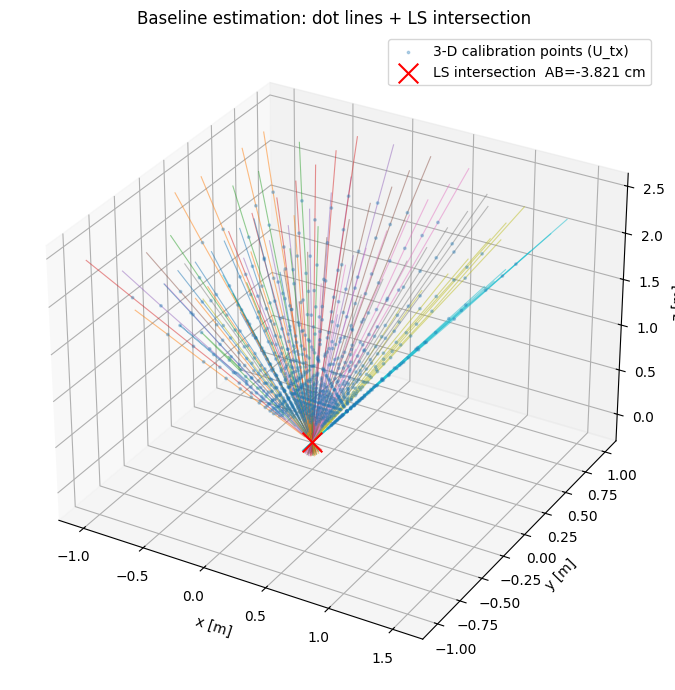

In [6]:
intersection, n_lines = dotCal.estimate_baseline(
    U_tx, outlier_sigma=BASELINE_OUTLIER_SIGMA, min_points=MIN_TRACK_POINTS)

B  = B_guess_vec + intersection
axis = 0 if mode == "x" else 1
AB = float(B[axis])

print(f"Fitted {n_lines} dot lines (after outlier removal)")
print(f"LS intersection (U_tx):  {intersection}")
print(f"B = {B}   (AB along {mode}: {AB*100:.4f} cm)")

# ── 3-D plot: points + lines + intersection ─────────────────────────────
all_pts = U_tx.reshape(-1, 3)
all_pts = all_pts[np.all(np.isfinite(all_pts), axis=1)]

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter(all_pts[:, 0], all_pts[:, 1], all_pts[:, 2],
           s=3, alpha=0.3, label="3-D calibration points (U_tx)")
cmap = plt.cm.tab10
for i in range(U_tx.shape[0]):
    pts = U_tx[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    if valid.sum() < 2:
        continue
    pts_v = pts[valid]
    direction = pts_v[-1] - pts_v[0]
    extended = np.vstack([(pts_v[0] - 0.3 * direction)[None, :], pts_v,
                          (pts_v[-1] + 0.3 * direction)[None, :]])
    ax.plot(extended[:, 0], extended[:, 1], extended[:, 2],
            color=cmap(i % 10), alpha=0.5, linewidth=0.8)
ax.scatter(*intersection, s=200, marker="x", color="red",
           label=f"LS intersection  AB={AB*100:.3f} cm")
ax.set_title("Baseline estimation: dot lines + LS intersection")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step4_baseline_3d", fig))
plt.show()

## Calibration Step 5: Unit Vector Estimation

For each dot i, fit a unit direction vector V[i] by minimising the angle between
the fitted ray and each calibration point Q_ij = U_ij − B (dots entering/leaving the FOV still get a V).

Unit vectors estimated: 100 / 100


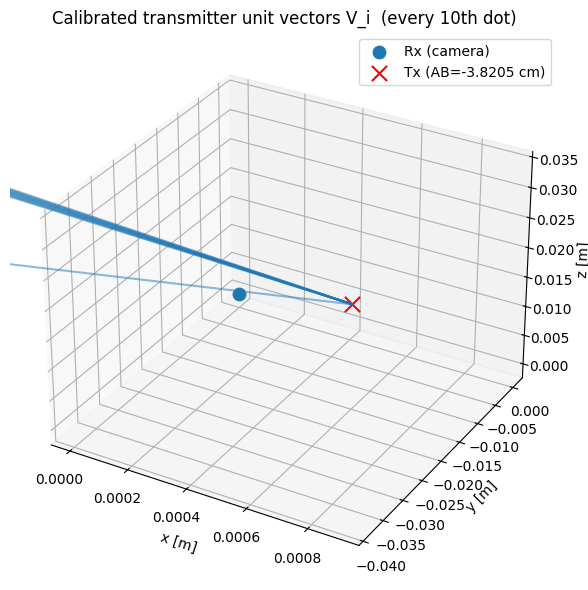

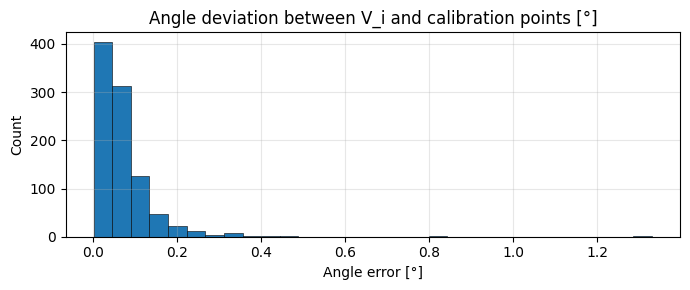

Median angle error: 0.04982°
Max angle error:    1.32996°


In [7]:
V = dotCal.estimate_unit_vectors(U, B)
V_valid = V[np.all(np.isfinite(V), axis=1)]
print(f"Unit vectors estimated: {len(V_valid)} / {V.shape[0]}")

angle_errs = []
for i in range(V.shape[0]):
    if not np.all(np.isfinite(V[i])):
        continue
    pts   = U[i, :, :]
    valid = np.all(np.isfinite(pts), axis=1)
    Q     = pts[valid] - B[None, :]
    Qn    = Q / (np.linalg.norm(Q, axis=1, keepdims=True) + 1e-12)
    angle_errs.extend(np.degrees(np.arccos(np.clip(Qn @ V[i], -1, 1))).tolist())

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
ax.scatter([0], [0], [0], s=80, marker="o", label="Rx (camera)")
ax.scatter([B[0]], [B[1]], [B[2]], s=120, marker="x", color="red",
           label=f"Tx (AB={AB*100:.4f} cm)")
for i in range(0, V.shape[0], 10):
    if not np.all(np.isfinite(V[i])):
        continue
    ax.quiver(B[0], B[1], B[2], V[i, 0], V[i, 1], V[i, 2],
              length=0.4, normalize=True, alpha=0.5)
ax.set_title("Calibrated transmitter unit vectors V_i  (every 10th dot)")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.legend()
plt.tight_layout()
calibration_figures.append(("step5_unit_vectors", fig))
plt.show()

plt.figure(figsize=(7, 3))
plt.hist(np.array(angle_errs), bins=30, edgecolor="k", linewidth=0.4)
plt.title("Angle deviation between V_i and calibration points [°]")
plt.xlabel("Angle error [°]"); plt.ylabel("Count")
plt.grid(alpha=0.3); plt.tight_layout()
calibration_figures.append(("step5_angle_error_hist", plt.gcf()))
plt.show()

print(f"Median angle error: {np.median(angle_errs):.5f}°")
print(f"Max angle error:    {np.max(angle_errs):.5f}°")

## Calibration Step 6: 1-D Dot Trails + Noise Estimates

The dot trails are precomputed as 1D Vector (Godbaz 4.2).

Calibration also measures the noise levels used by Approach 2:
- **σ_u** [px]: residual of all detections to their trail line
- **σ_ToF(z)**: robust std of the dots ToF depths per distance

Trails: 100 dots, 50 samples on average (z: 0.4 m -> ∞)
sigma_u (2-D cal residual) = 0.2427 px
sigma_u_ab (1-D runtime AB) = 0.3403 px
sigma_ToF(z):
  z = 0.402 m  ->  σ = 5.75 mm
  z = 0.437 m  ->  σ = 5.49 mm
  z = 0.482 m  ->  σ = 4.95 mm
  z = 0.539 m  ->  σ = 4.75 mm
  z = 0.612 m  ->  σ = 5.12 mm
  z = 0.709 m  ->  σ = 7.43 mm
  z = 0.851 m  ->  σ = 6.92 mm
  z = 1.052 m  ->  σ = 9.49 mm
  z = 1.376 m  ->  σ = 14.80 mm
  z = 1.984 m  ->  σ = 10.37 mm


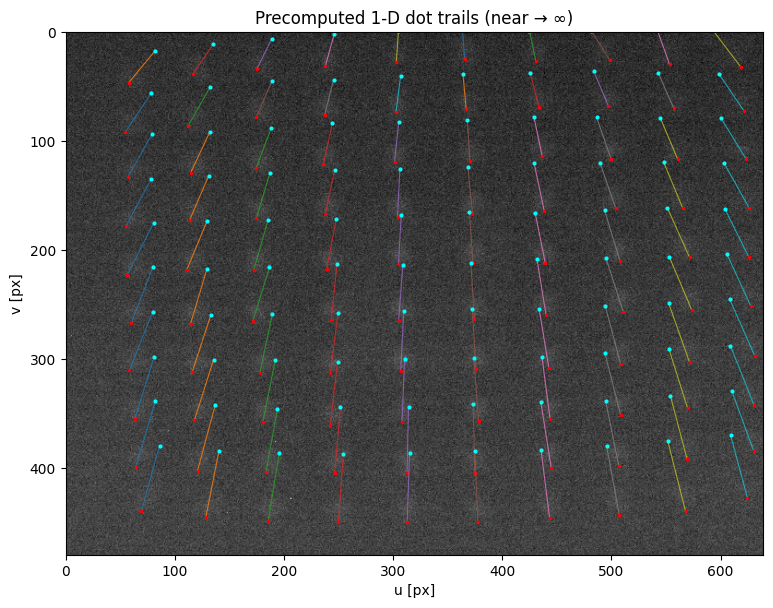

In [8]:
image_shape = image.shape[:2]
TRAIL_Z_MIN = 0.4  # trails run from here to infinity [m] (Godbaz: ~30 cm)
trails = dotCal.fit_trails_from_detections(
    subpixel_list, U, z_min=TRAIL_Z_MIN, step_px=1.0,
    image_shape=image_shape, V=V, B=B, K=K)
n_trails = sum(1 for t in trails if t is not None)
lens = [len(t["u"]) for t in trails if t is not None]
print(f"Trails: {n_trails} dots, {int(np.mean(lens))} samples on average "
      f"(z: {TRAIL_Z_MIN} m -> ∞)")

sigma_u = dotCal.estimate_sigma_u_trails(subpixel_list, trails)
sigma_tof_table = dotCal.estimate_sigma_tof(U, expected_z=cal_dists)
sl_paths = [calibrate.find_sl_image(sl_cal, Path(p).name) for p in tof_paths]
sigma_u_ab = calibrate.estimate_sigma_u_ab(dotCal, subpixel_list, trails, sl_paths, TRAIL_Z_MIN)
print(f"sigma_u (2-D cal residual) = {sigma_u:.4f} px")
print(f"sigma_u_ab (1-D runtime AB) = {sigma_u_ab:.4f} px")
print("sigma_ToF(z):")
for z, s in sigma_tof_table:
    print(f"  z = {z:.3f} m  ->  σ = {s*1e3:.2f} mm")

# ── Trail visualization 
fig = dotCal.plot_dot_trails(trails, image_shape=image_shape, background=image)
calibration_figures.append(("step6_dot_trails", fig))
plt.show()

## Save Calibration

Writes the extended `calibration.json` (incl. mode, full 3-D B, precomputed trails,
σ_u, σ_ToF table) to `Calibrations/<CAL_NAME>/`. Set `CAL_NAME`/`SAVE_PLOTS` below.

In [8]:
import json as _json
from datetime import datetime as _dt

CAL_NAME   = f"{CAMERA}_paperlike"   # -> Calibrations/<CAL_NAME>/calibration.json
SAVE_PLOTS = True

cal_dir = Path.cwd().parent / "Calibrations" / CAL_NAME
cal_dir.mkdir(parents=True, exist_ok=True)

cal_data = calibrate.sanitize({
    "metadata": {
        "created": _dt.now().isoformat(),
        "camera": CAMERA,
        "sl_cal_path": str(sl_cal),
        "tof_cal_path": str(tof_cal),
        "pipeline": "codePaperlike",
        "mode": mode,
        "baseline_guess": B_guess_vec.tolist(),
        "subpixel_mode": SUBPIXEL_MODE,
        "pcd_depth_mode": "radial",
        "tof_sample": TOF_SAMPLE,
        "pcd_unit_scale": 0.001,
        "track_in_tx_space": TRACK_IN_TX_SPACE,
        "baseline_outlier_sigma": BASELINE_OUTLIER_SIGMA,
        "baseline_min_points": MIN_TRACK_POINTS,
        "trail_z_min": TRAIL_Z_MIN,
        "fx": float(fx), "fy": float(fy),
        "cx": float(cx), "cy": float(cy),
    },
    "mode": mode,
    "K": K.tolist(),
    "K_inv": K_inv.tolist(),
    "V": V.tolist(),
    "B": B.tolist(),
    "AB": AB,
    "BASELINE_GUESS": B_guess_vec.tolist(),
    "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "U": U.tolist(),
    "trails": [None if t is None else
               {"u": t["u"].tolist(), "v": t["v"].tolist(), "w": t["w"].tolist()}
               for t in trails],
    "sigma_u": float(sigma_u),
    "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table.tolist(),
})

cal_file = cal_dir / "calibration.json"
with open(cal_file, "w") as f:
    _json.dump(cal_data, f)
print(f"Calibration saved to {cal_file}")

if SAVE_PLOTS:
    for name, fig in calibration_figures:
        fig.savefig(str(cal_dir / f"{name}.png"), dpi=150, bbox_inches="tight")
    print(f"Saved {len(calibration_figures)} plot(s) to {cal_dir}")

Calibration saved to /home/julian/Documents/Github/iToF-SL-Combination/Calibrations/SchmersalReal_paperlike/calibration.json


Saved 6 plot(s) to /home/julian/Documents/Github/iToF-SL-Combination/Calibrations/SchmersalReal_paperlike


## Noise / Repeatability Measurement

Everything above is the **unchanged** calibration pipeline of `iToF_SL_fusion_pipeline.ipynb`.

From here on the notebook no longer evaluates a single test frame. It sweeps the repeatability
dataset

```
/home/julian/Documents/Calibrations/RauschmessungiToF10x10450375050step/ToFPCD/<d>m/Nr<0..99>.pcd
```

— 67 distances (0.45 m … 3.75 m in 5 cm steps) × 100 repeated captures of the same static flat
wall = **6700 frames**. Every frame is pushed through **all three approaches** (20 100 runs), so
for each of the 100 dots at each distance we get a distribution of 100 depth measurements.

From that we read off

* the **per-dot** noise — a 10×10 grid of error histograms laid out like the dot pattern
  (top-left = grid position (0,0), bottom-right = (9,9)), for freely selectable distances, and
* the **overall** noise per distance — σ vs. distance, one curve per approach.

The active-brightness images the approaches need are generated once from the same PCDs with
`pcdToExr.py` (the `grayValue` field → single-channel EXR).

`DISTANCE_RANGE` in the configuration cell restricts every table and figure below to a
sub-range — set it to `[0.40, 2.00]` to work on the near half first. Changing it is free: the
sweep is checkpointed per distance, so a narrower (or wider) range only re-assembles cached
results instead of re-running any frame.

> **Caveat, Approach 2 only.** `cal["sigma_tof_table"]` spans 0.402 – 2.0 m and
> `approaches.sigma_models` interpolates it with `np.interp`, which *clamps* outside that range.
> Beyond 2 m Approach 2 therefore weights iToF with the σ measured at 2.0 m. That shifts the
> fusion weights; it does not affect the measured σ of Approaches 1 and 3.

In [18]:
# ── Noise-sweep configuration ────────────────────────────────────────────────
# Deliberately free of calibration dependencies, so cells 21+ can re-plot from the
# cached .npz in a fresh kernel with only this cell and the import cell run.
import contextlib
import io
import multiprocessing as mp
import re
import subprocess
import sys
import time
import warnings

NOISE_PCD_ROOT = Path("/home/julian/Documents/Calibrations/"
                      "RauschmessungiToF10x10450375050step/ToFPCD")
NOISE_EXR_ROOT = Path("/home/julian/Documents/Calibrations/RauschmessungEXR")
CACHE_DIR      = Path.cwd().parent / "Results" / "noise_estimation"
RESULT_NPZ     = CACHE_DIR / f"noise_summary{SOR_TAG}.npz"   # SOR_TAG from the cell above

N_WORKERS       = 5      # 0 → run serially (easier to debug)
FORCE_RERUN     = False  # True → redo the EXR conversion and the sweep, ignoring caches
MIN_VALID       = 10     # repeats a dot needs before its σ is reported
# Which distances to analyse. Narrowing this re-runs NOTHING — the sweep is
# checkpointed per distance, so the range only selects which cached blocks are
# assembled and therefore which distances every table and figure below covers.
DISTANCE_RANGE  = [0.40, 1.20]   # [lower, upper] ground truth [m], inclusive;
                                 # None → the whole 0.45 … 3.75 m sweep
LIMIT_DISTANCES = None   # e.g. 2 → smoke test on the first two distances only

CACHE_DIR.mkdir(parents=True, exist_ok=True)

SERIES = [
    "Approach 1 — consistency error (ToF @ min-ε)",
    "Approach 2 — Gaussian ML fusion",
    "Approach 3 — active brightness (triangulated)",
    "Approach 2 input: iToF only",
    "Approach 2 input: SL only",
]
N_SERIES = len(SERIES)

# Okabe–Ito, assigned in fixed order — never cycled, never reassigned when a
# series is hidden, so a colour always means the same approach.
SERIES_COLOR = ["#0072B2", "#D55E00", "#009E73", "#56B4E9", "#CC79A7"]
SERIES_STYLE = ["-", "-", "-", "--", "--"]
SERIES_LW    = [2.0, 2.0, 2.0, 1.2, 1.2]

_rng = ("0.45 … 3.75 m (all)" if DISTANCE_RANGE is None
        else f"{DISTANCE_RANGE[0]:.2f} … {DISTANCE_RANGE[1]:.2f} m")
print(f"{N_SERIES} result series  |  distance range: {_rng}")
print(f"PCD root : {NOISE_PCD_ROOT}")
print(f"EXR root : {NOISE_EXR_ROOT}")
print(f"cache    : {CACHE_DIR}")
print(f"outliers : " + (f"SOR on, {SOR_K} pts / {SOR_NSIGMA:.2f} σ" if SOR_ENABLED
                        else "SOR off (raw clouds)") + f"  → {RESULT_NPZ.name}")

5 result series  |  distance range: 0.40 … 1.20 m
PCD root : /home/julian/Documents/Calibrations/RauschmessungiToF10x10450375050step/ToFPCD
EXR root : /home/julian/Documents/Calibrations/RauschmessungEXR
cache    : /home/julian/Documents/Github/iToF-SL-Combination/Results/noise_estimation
outliers : SOR on, 6 pts / 1.00 σ  → noise_summary_sor6-1.00_cap0.00-2.00.npz


### Step A — Active-brightness EXRs

The approaches read the SL/active-brightness image through `DotCalibration.read_image`, so the
`grayValue` field of every noise PCD is exported once to a single-channel EXR with the repo's
`pcdToExr.py` (unmodified). Idempotent: the cell skips the conversion once the EXR count matches
the PCD count.

In [19]:
# ── Step A: convert every noise PCD to a single-channel AB EXR ───────────────
# Uses the repo's pcdToExr.py unchanged: it reads the PCD `grayValue` field and
# writes it to the channel `DotCalibration.SL_CHANNEL`, mirroring the folder
# structure (…/ToFPCD/0.45m/Nr0.pcd → …/RauschmessungEXR/0.45m/Nr0.exr).
n_pcd = sum(1 for _ in NOISE_PCD_ROOT.rglob("*.pcd"))
n_exr = sum(1 for _ in NOISE_EXR_ROOT.rglob("*.exr")) if NOISE_EXR_ROOT.exists() else 0
print(f"{n_pcd} PCDs  |  {n_exr} EXRs already present")

if FORCE_RERUN or n_exr != n_pcd:
    script = Path.cwd().parent / "pcdToExr.py"
    cmd = [sys.executable, str(script), str(NOISE_PCD_ROOT), str(NOISE_EXR_ROOT)]
    print("running:", " ".join(cmd), "\n(this reads ~93 GB and writes ~8 GB — a few minutes)")
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    for line in proc.stdout.strip().splitlines()[-3:]:
        print(" ", line)
    if proc.returncode != 0:
        print("STDERR:", proc.stderr[-2000:])
    print(f"conversion took {time.time() - t0:.0f} s")
    n_exr = sum(1 for _ in NOISE_EXR_ROOT.rglob("*.exr"))
    print(f"{n_exr}/{n_pcd} EXRs now present")
else:
    print("EXRs complete — skipping conversion (set FORCE_RERUN = True to redo)")

# Spot check: does the EXR read back through the same loader the approaches use?
# SOR is geometric — it NaNs xyz, never grayValue — so intensity_map is identical
# to the raw cloud's and this comparison stays exact with the filter on.
probe_exr = NOISE_EXR_ROOT / "0.45m" / "Nr0.exr"
probe_pcd = NOISE_PCD_ROOT / "0.45m" / "Nr0.pcd"
if probe_exr.exists():
    img = dotCal.read_image(str(probe_exr))
    ref = dotCal.load_tof_pcd(str(probe_pcd), unit_scale=0.001,
                              depth_mode="axial")["intensity_map"]
    print(f"spot check {probe_exr.relative_to(NOISE_EXR_ROOT)}: shape={img.shape} "
          f"dtype={img.dtype} range={img.min():.1f}..{img.max():.1f}  "
          f"max|EXR-grayValue| = {np.nanmax(np.abs(img - ref)):.3g}")

6700 PCDs  |  6700 EXRs already present
EXRs complete — skipping conversion (set FORCE_RERUN = True to redo)
spot check 0.45m/Nr0.exr: shape=(480, 640) dtype=float32 range=159.1..557.7  max|EXR-grayValue| = 0


### Step B — 10×10 display layout

The requested figure layout is *grid position*, not dot ID. The mapping is derived from the
calibration detections, so `grid_ids[0, 0]` is the top-left dot and `grid_ids[9, 9]` the
bottom-right one.

In [20]:
# ── Step B: 10×10 display layout ─────────────────────────────────────────────
# Dot IDs come from the NN tracker and are NOT grid positions: ids 20…99 happen to
# match rows 2…9, but ids 0…19 interleave the top two rows (dot 0 sits at y≈73,
# dot 1 at y≈33). Derive the layout from the calibration detections at a distance
# where all dots were found: sort by y → ten rows → sort each row by x.
N_DOTS = len(trails)
assert N_DOTS == 100, f"expected a 10×10 pattern, got {N_DOTS} trails"

_full = next(s for s in subpixel_list if len(s) == N_DOTS)
_ids = np.array([d["id"] for d in _full])
_x   = np.array([d["x"] for d in _full], float)
_y   = np.array([d["y"] for d in _full], float)

_rows = np.argsort(_y).reshape(10, 10)                              # ten y-bands
grid_ids = np.array([_ids[r[np.argsort(_x[r])]] for r in _rows])    # (10, 10)

assert sorted(grid_ids.ravel().tolist()) == list(range(N_DOTS)), "layout is not a permutation"
print("Display grid (row 0 = top of the image, column 0 = left):")
for r in range(10):
    ys = _y[[int(np.where(_ids == g)[0][0]) for g in grid_ids[r]]]
    print("  " + " ".join(f"{g:3d}" for g in grid_ids[r])
          + f"   | y = {ys.min():3.0f}…{ys.max():3.0f} px")

Display grid (row 0 = top of the image, column 0 = left):
    1   3   4   6   8  10  12  15  16  18   | y =   8… 30 px
    0   2   5   7   9  11  13  14  17  19   | y =  49… 71 px
   20  21  22  23  24  25  26  27  28  29   | y =  93…112 px
   30  31  32  33  34  35  36  37  38  39   | y = 137…155 px
   40  41  42  43  44  45  46  47  48  49   | y = 181…197 px
   50  51  52  53  54  55  56  57  58  59   | y = 224…239 px
   60  61  62  63  64  65  66  67  68  69   | y = 267…283 px
   70  71  72  73  74  75  76  77  78  79   | y = 311…328 px
   80  81  82  83  84  85  86  87  88  89   | y = 354…371 px
   90  91  92  93  94  95  96  97  98  99   | y = 396…414 px


### Step C — The sweep

6700 frames × 3 approaches. One `common_setup` per frame feeds all three runners, all plotting is
off, and every runner's stdout is swallowed. Work is spread over `N_WORKERS` forked processes and
checkpointed per distance in `Results/noise_estimation/`, so the run resumes after an interrupt.

Alongside the three approach outputs, Approach 2's two *inputs* (the iToF depth and the
triangulated SL depth at the same dot) are recorded — they come for free from
`ab_trail_candidates` and show what the fusion is actually fusing.

Expect roughly 5–8 minutes on 5 cores; ~20 minutes serially.

In [21]:
# ── Step C: the sweep — 6700 frames × 3 approaches ───────────────────────────
# Per frame: one common_setup (PCD + EXR load) feeds all three approaches.
# Results are checkpointed per distance, so an interrupted run resumes. The
# checkpoint names carry SOR_TAG, so a filtered and an unfiltered sweep never
# share a file and can be compared by flipping SOR_ENABLED.

# Calibration dict handed to approaches.py — identical to the fusion notebook's.
cal = {
    "K": K, "K_inv": K_inv, "V": V, "B": B,
    "AB": AB, "mode": mode,
    "U": U, "cal_dists": [float(d) for d in cal_dists],
    "subpixel_list": subpixel_list,
    "trails": trails,
    "sigma_u": float(sigma_u), "sigma_u_ab": float(sigma_u_ab),
    "sigma_tof_table": sigma_tof_table,
    "metadata": {"pcd_unit_scale": 0.001, "trail_z_min": TRAIL_Z_MIN, "mode": mode},
}

def _dist_of(folder):
    """Ground truth [m] from a folder name like '0.50m'.

    `parse_distance_from_name` runs `os.path.splitext` first, which would eat
    '.50m' as the extension — appending a dummy suffix keeps the stem intact.
    """
    d = dotCal.parse_distance_from_name(folder.name + ".pcd")
    if d is None:
        raise ValueError(f"cannot parse a distance from folder {folder.name!r}")
    return float(d)


dist_dirs = sorted((p for p in NOISE_PCD_ROOT.iterdir() if p.is_dir()), key=_dist_of)
n_all = len(dist_dirs)
if DISTANCE_RANGE is not None:
    _lo, _hi = DISTANCE_RANGE
    dist_dirs = [p for p in dist_dirs if _lo - 1e-9 <= _dist_of(p) <= _hi + 1e-9]
    if not dist_dirs:
        raise ValueError(f"DISTANCE_RANGE {DISTANCE_RANGE} selects none of the "
                         f"{n_all} measured distances")
if LIMIT_DISTANCES:
    dist_dirs = dist_dirs[:LIMIT_DISTANCES]
dists = np.array([_dist_of(p) for p in dist_dirs], float)
print(f"{len(dist_dirs)} of {n_all} distances: {dists.min():.2f} … {dists.max():.2f} m "
      f"({len(dist_dirs) * 100} frames × 3 approaches)")

_W = {}


def _init_worker(cal_dict):
    """One DotCalibration + calibration dict per worker process."""
    _W["dotCal"] = DotCalibration()
    _W["cal"] = cal_dict


def _run_frame(task):
    """All three approaches on one frame. Returns (repeat_index, (N_SERIES, N_DOTS))."""
    dname, k = task
    out = np.full((N_SERIES, N_DOTS), np.nan, np.float32)
    sl_p = str(NOISE_EXR_ROOT / dname / f"Nr{k}.exr")
    tof_p = str(NOISE_PCD_ROOT / dname / f"Nr{k}.pcd")
    d, c = _W["dotCal"], _W["cal"]
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            setup = approaches.common_setup(d, c, sl_p, tof_p)
            r1 = approaches.run_approach_1(d, c, setup, make_plots=False)
            r2 = approaches.run_approach_2(d, c, setup, make_plots=False)
            r3 = approaches.run_approach_3(d, c, setup, make_plots=False)
    except Exception as exc:                                    # noqa: BLE001
        print(f"  [warn] {dname}/Nr{k}: {type(exc).__name__}: {exc}")
        return k, out
    # index by r["i"] (the dot id) — the runners skip uncalibrated trails
    for r in r1["results"]:
        out[0, r["i"]] = r["Z_out"]
    for r in r2["results"]:
        out[1, r["i"]] = r["z_fus"]
        if np.isfinite(r["z_fus"]):          # same gate the fusion applied
            out[3, r["i"]] = r["z_tof"]
            out[4, r["i"]] = r["z_sl"]
    for r in r3["results"]:
        out[2, r["i"]] = r["Z_out"]
    return k, out


def run_sweep():
    ctx = mp.get_context("fork")     # children inherit the notebook globals
    pool = ctx.Pool(N_WORKERS, initializer=_init_worker, initargs=(cal,)) if N_WORKERS else None
    if pool is None:
        _init_worker(cal)
    t_start, n_done = time.time(), 0
    todo = [f for f in dist_dirs
            if FORCE_RERUN or not (CACHE_DIR / f"d_{f.name}{SOR_TAG}.npz").exists()]
    print(f"{len(dist_dirs) - len(todo)} distances cached, {len(todo)} to run")
    try:
        for folder in todo:
            ks = sorted(int(re.search(r"Nr(\d+)", p.stem).group(1))
                        for p in folder.glob("*.pcd"))
            pos = {k: j for j, k in enumerate(ks)}
            block = np.full((N_SERIES, len(ks), N_DOTS), np.nan, np.float32)
            tasks = [(folder.name, k) for k in ks]
            it = (pool.imap_unordered(_run_frame, tasks, chunksize=4) if pool
                  else map(_run_frame, tasks))
            for k, arr in it:
                block[:, pos[k], :] = arr
            np.savez_compressed(CACHE_DIR / f"d_{folder.name}{SOR_TAG}.npz", block=block,
                                repeats=np.array(ks, np.int32),
                                dist=_dist_of(folder))
            n_done += 1
            el = time.time() - t_start
            eta = el / n_done * (len(todo) - n_done)
            frac = np.isfinite(block[:3]).mean(axis=(1, 2))
            print(f"[{n_done}/{len(todo)}] {folder.name}: {len(ks)} frames, "
                  f"valid A1/A2/A3 = {frac[0]:.0%}/{frac[1]:.0%}/{frac[2]:.0%}  "
                  f"| {el/60:.1f} min elapsed, ~{eta/60:.1f} min left")
    finally:
        if pool is not None:
            pool.close()
            pool.join()


run_sweep()

# ── assemble the selected blocks into Z[series, distance, repeat, dot] ───────
# Only the distances inside DISTANCE_RANGE go into RESULT_NPZ, so cells 25+ follow
# the range with no further edits. The per-distance d_*.npz checkpoints are never
# pruned — widening the range again costs a re-assembly, not a re-run.
blocks = [np.load(CACHE_DIR / f"d_{f.name}{SOR_TAG}.npz")["block"] for f in dist_dirs]
n_rep = max(b.shape[1] for b in blocks)
Z = np.full((N_SERIES, len(dist_dirs), n_rep, N_DOTS), np.nan, np.float32)
for di, b in enumerate(blocks):
    Z[:, di, :b.shape[1], :] = b
np.savez_compressed(RESULT_NPZ, Z=Z, dists=dists, grid_ids=grid_ids,
                    series=np.array(SERIES), min_valid=MIN_VALID)
print(f"\nZ{Z.shape} (series, distance, repeat, dot) → {RESULT_NPZ} "
      f"({RESULT_NPZ.stat().st_size / 1e6:.1f} MB)")

16 of 67 distances: 0.45 … 1.20 m (1600 frames × 3 approaches)
16 distances cached, 0 to run

Z(5, 16, 100, 100) (series, distance, repeat, dot) → /home/julian/Documents/Github/iToF-SL-Combination/Results/noise_estimation/noise_summary_sor6-1.00_cap0.00-2.00.npz (2.4 MB)


### Step D — Per-dot statistics

For every (approach, distance, dot): the temporal σ over the repeats, the mean bias against the
ground truth taken from the folder name, and the number of valid repeats (dots rejected by the
ε-gate produce NaN). A dot needs at least `MIN_VALID` valid repeats before its σ is reported.

In [22]:
# ── Step D: per-dot statistics ───────────────────────────────────────────────
# Reload from disk so the plotting cells below work in a fresh kernel without
# re-running the sweep.
#
# Three things are computed here that the first version of this cell did not
# have, because without them the summary plot is misleading:
#
#   * rmse_dot — σ alone is *repeatability*, not accuracy. Approach 3 reads its
#     depth off a quadratic vertex fitted to a Gaussian-smoothed brightness
#     profile, which turns random error into bias: its σ is tiny while its bias
#     grows to tens of mm. Only RMSE = √(σ² + bias²) ranks the approaches fairly.
#   * common_dots — approach 1 is valid for ~100 % of the dots, while A2/A3/iToF/SL
#     share a gate (|1/z_tof − 1/z_sl| ≤ ε) that keeps as few as 12 of 100 dots at
#     the far end. Aggregating each series over its own survivors compares 100
#     dots against a dozen hand-picked ones.
#   * gross_frac — the fraction of single measurements further than GROSS_MM from
#     ground truth. Separates "noisy" from "picked the wrong trail sample".
#
# STAT also matters: the per-dot σ is strongly right-skewed (for approach 1 the
# mean runs up to 57× its median), so a mean over dots plots the outliers, not
# the sensor.
STAT             = "median"   # "mean" → the original, outlier-driven view
COMMON_DOTS_ONLY = True       # score every series on the same dots
GROSS_MM         = 50.0       # a single measurement further off than this is "gross"

_npz = np.load(RESULT_NPZ, allow_pickle=False)
Z = _npz["Z"]
dists = _npz["dists"]
grid_ids = _npz["grid_ids"]
SERIES = [str(s) for s in _npz["series"]]
N_SERIES, N_DIST, N_REP, N_DOTS = Z.shape

valid = np.isfinite(Z) & (Z > 1e-6)
Zv = np.where(valid, Z, np.nan).astype(np.float64)
err = Zv - dists[None, :, None, None]           # signed error per measurement [m]

with warnings.catch_warnings():                 # all-NaN dots are expected
    warnings.simplefilter("ignore", RuntimeWarning)
    nvalid    = valid.sum(axis=2)                       # (S, D, N)
    sigma_dot = np.nanstd(Zv, axis=2)                   # temporal σ per dot [m]
    mean_dot  = np.nanmean(Zv, axis=2)                  # per-dot mean depth [m]
    rmse_dot  = np.sqrt(np.nanmean(err ** 2, axis=2))   # per-dot RMSE vs GT [m]
    gross_dot = np.nanmean(np.abs(err) > GROSS_MM * 1e-3, axis=2)

too_few = nvalid < MIN_VALID
for _a in (sigma_dot, mean_dot, rmse_dot, gross_dot):
    _a[too_few] = np.nan
bias_dot = mean_dot - dists[None, :, None]              # per-dot bias vs GT [m]

# Dots that survive in EVERY series at this distance — the only fair comparison set.
common_dots = np.all(np.isfinite(sigma_dot), axis=0)    # (D, N)
n_common = common_dots.sum(axis=1)                      # (D,)
_score = np.where(common_dots[None, :, :], True, not COMMON_DOTS_ONLY)


def _agg(a, how=None):
    """Aggregate a per-dot quantity (S, D, N) over the dots → (S, D)."""
    how = STAT if how is None else how
    m = np.where(_score, a, np.nan)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        if how == "mean":
            return np.nanmean(m, axis=2)
        if how == "median":
            return np.nanmedian(m, axis=2)
        return np.nanpercentile(m, float(how), axis=2)


sigma_c = _agg(sigma_dot)
sigma_p10 = _agg(sigma_dot, 10)
sigma_p90 = _agg(sigma_dot, 90)
rmse_c  = _agg(rmse_dot)
rmse_p10 = _agg(rmse_dot, 10)
rmse_p90 = _agg(rmse_dot, 90)
bias_c  = _agg(bias_dot)
gross_c = _agg(gross_dot, "mean")          # a rate is always averaged, never medianed
valid_frac = nvalid.mean(axis=2) / N_REP   # (S, D)

# Kept under the old names so Result 1 and Result 3 below need no changes.
sigma_mean, bias_mean = sigma_c, bias_c

_set = f"common dots only (n = {n_common.min()}…{n_common.max()})" if COMMON_DOTS_ONLY \
       else "each series over its own valid dots"
print(f"Z{Z.shape}   |   MIN_VALID = {MIN_VALID} repeats per dot")
print(f"statistic over dots: {STAT}   |   {_set}   |   gross = |err| > {GROSS_MM:.0f} mm\n")

_w = 8
print(f"{'dist':>7}{'#com':>6} " + " ".join(f"{('σ A%d' % (s + 1)):>{_w}}" for s in range(3))
      + "  " + " ".join(f"{('RMSE A%d' % (s + 1)):>{_w}}" for s in range(3))
      + "  " + " ".join(f"{('gross A%d' % (s + 1)):>{_w}}" for s in range(3)))
for di in range(0, N_DIST, max(1, N_DIST // 12)):
    print(f"{dists[di]:>6.2f}m{n_common[di]:>6d} "
          + " ".join(f"{sigma_c[s, di] * 1e3:>{_w}.2f}" for s in range(3))
          + "  " + " ".join(f"{rmse_c[s, di] * 1e3:>{_w}.2f}" for s in range(3))
          + "  " + " ".join(f"{gross_c[s, di]:>{_w}.1%}" for s in range(3)))
print("\nσ and RMSE in mm. σ is repeatability, RMSE is accuracy — they rank the "
      "approaches differently,\nwhich is the whole point of carrying both.")


Z(5, 16, 100, 100)   |   MIN_VALID = 10 repeats per dot
statistic over dots: median   |   common dots only (n = 52…97)   |   gross = |err| > 50 mm

   dist  #com     σ A1     σ A2     σ A3   RMSE A1  RMSE A2  RMSE A3  gross A1 gross A2 gross A3
  0.45m    52     0.68     0.16     0.05      3.52     5.19     5.47      0.0%     0.0%     0.0%
  0.50m    93     0.76     0.33     0.04      5.80     7.17     7.87      0.0%     0.0%     0.0%
  0.55m    94     0.85     0.46     0.04      8.49     8.98     9.40      0.0%     0.0%     0.0%
  0.60m    94     0.97     0.59     0.05      9.92    10.32    10.80      0.0%     0.0%     0.0%
  0.65m    94     1.11     0.68     0.06     11.21    12.14    11.04      0.0%     0.0%     0.0%
  0.70m    95     1.31     0.68     0.08     12.29    12.76    13.18      0.0%     0.0%     0.0%
  0.75m    95     1.48     0.91     0.11     11.56    12.01    12.28      0.0%     0.0%     2.0%
  0.80m    96     1.65     1.12     0.14      9.49    10.12    13.44      0.

## Result 1 — per-dot distributions (10×10)

One figure per (approach, distance): each of the 100 panels is one dot, laid out like the
projected pattern — top-left is grid position (0,0), top-right (0,9), bottom-left (9,0),
bottom-right (9,9). Each panel shows the histogram of that dot's 100 measurements as an error
against the ground truth, on a shared x-axis so panels compare directly.

Set `SHOW_DISTANCES` and `SHOW_APPROACHES` to choose what is drawn.

outside the selected range (0.45 … 1.20 m), skipped: 1.50 m, 2.00 m


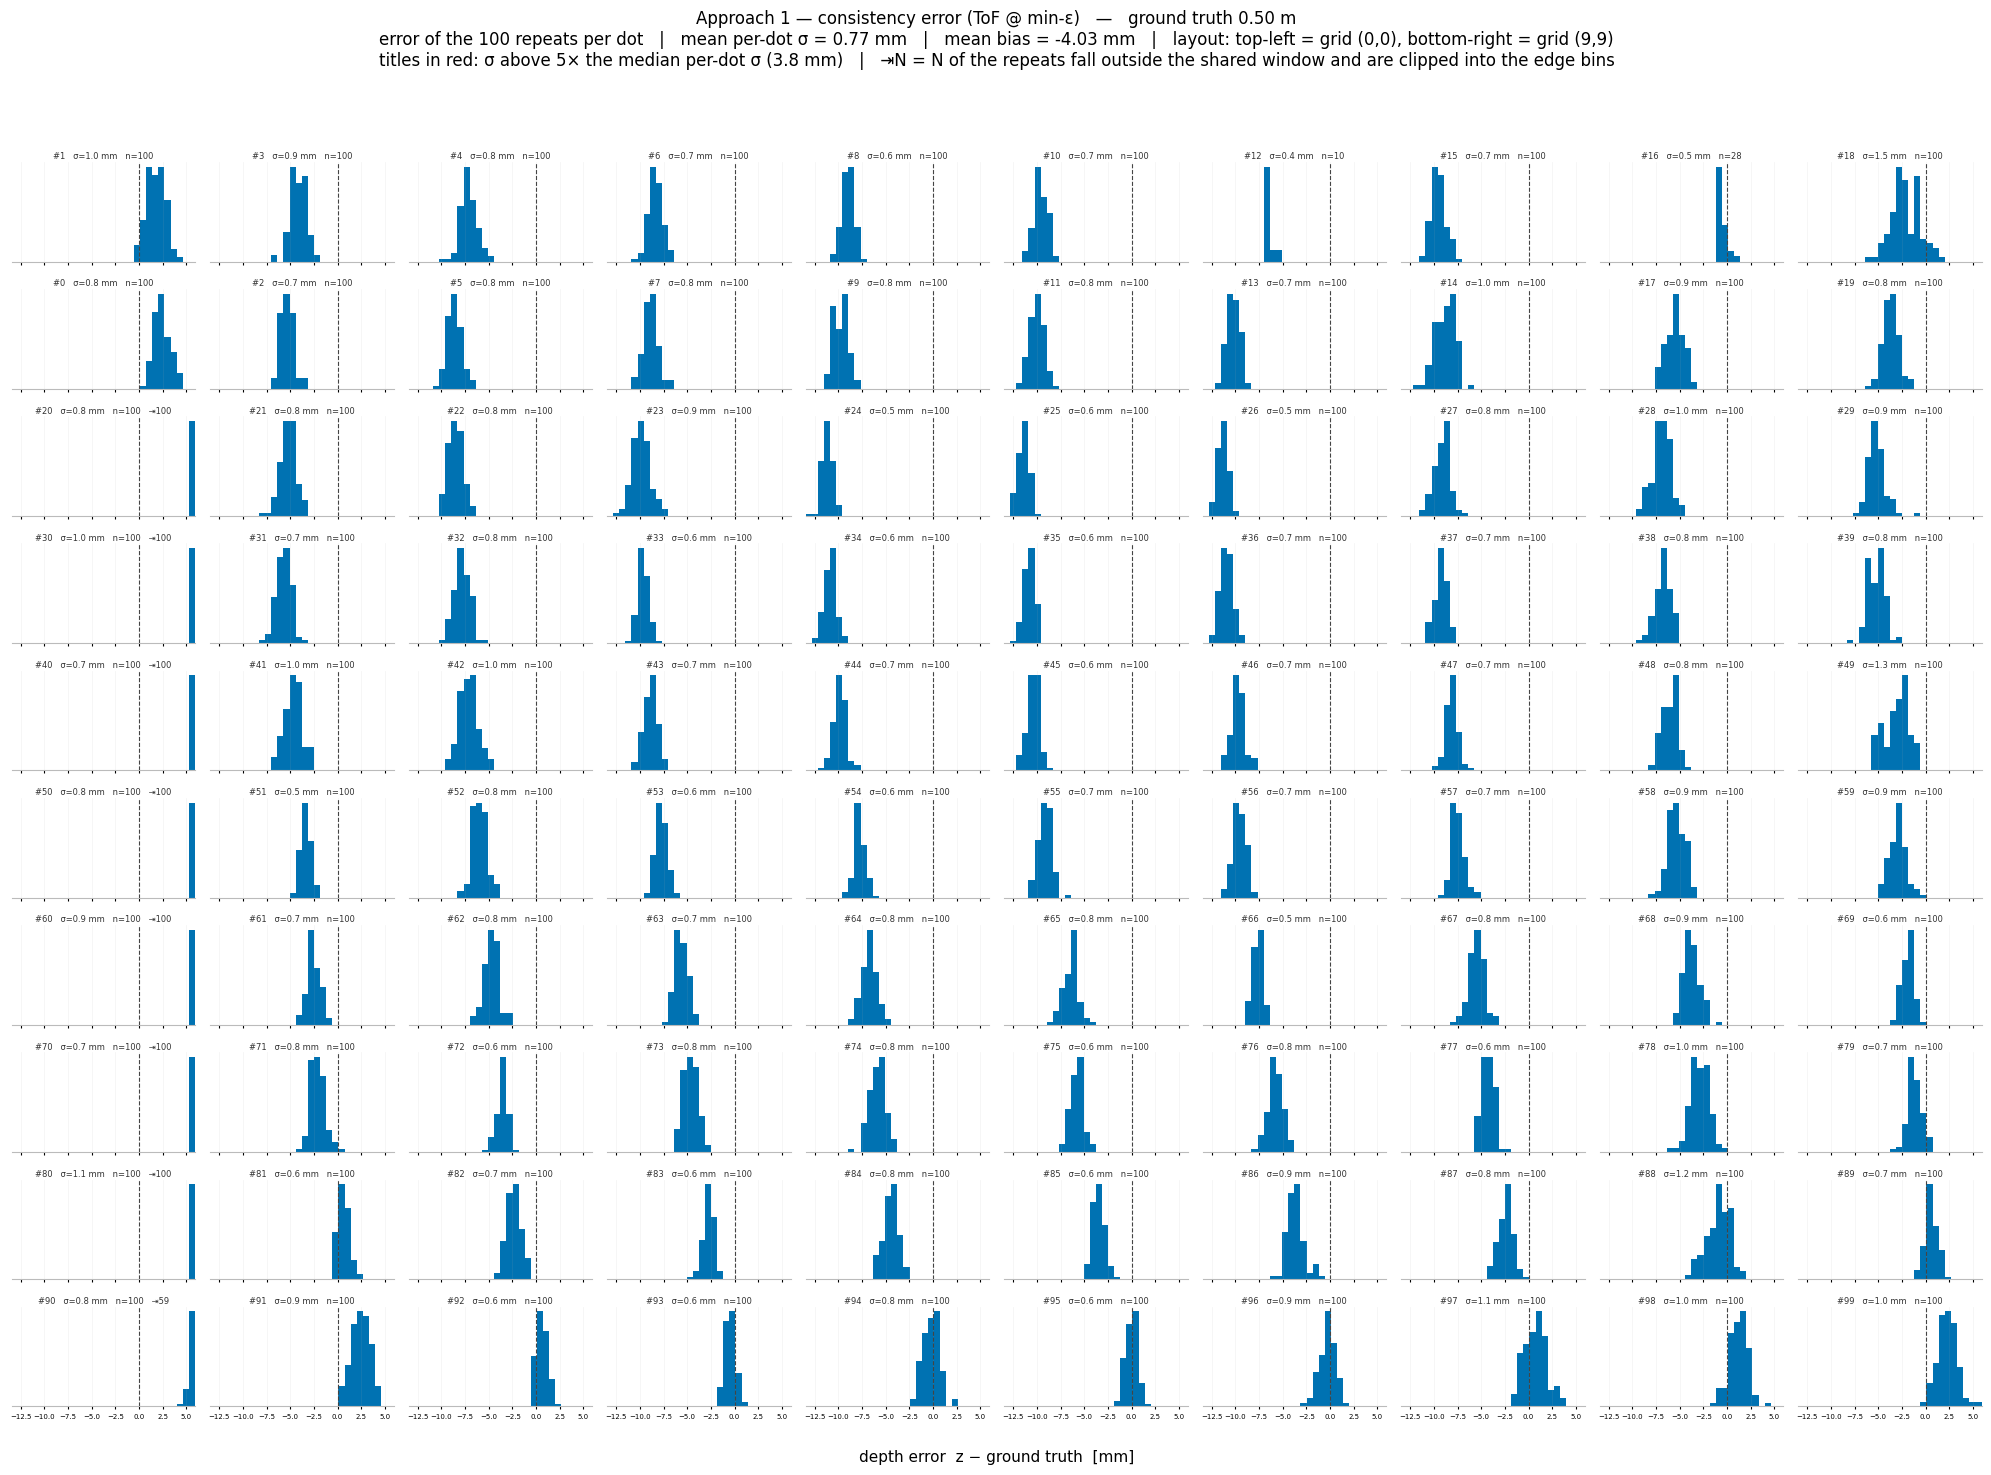

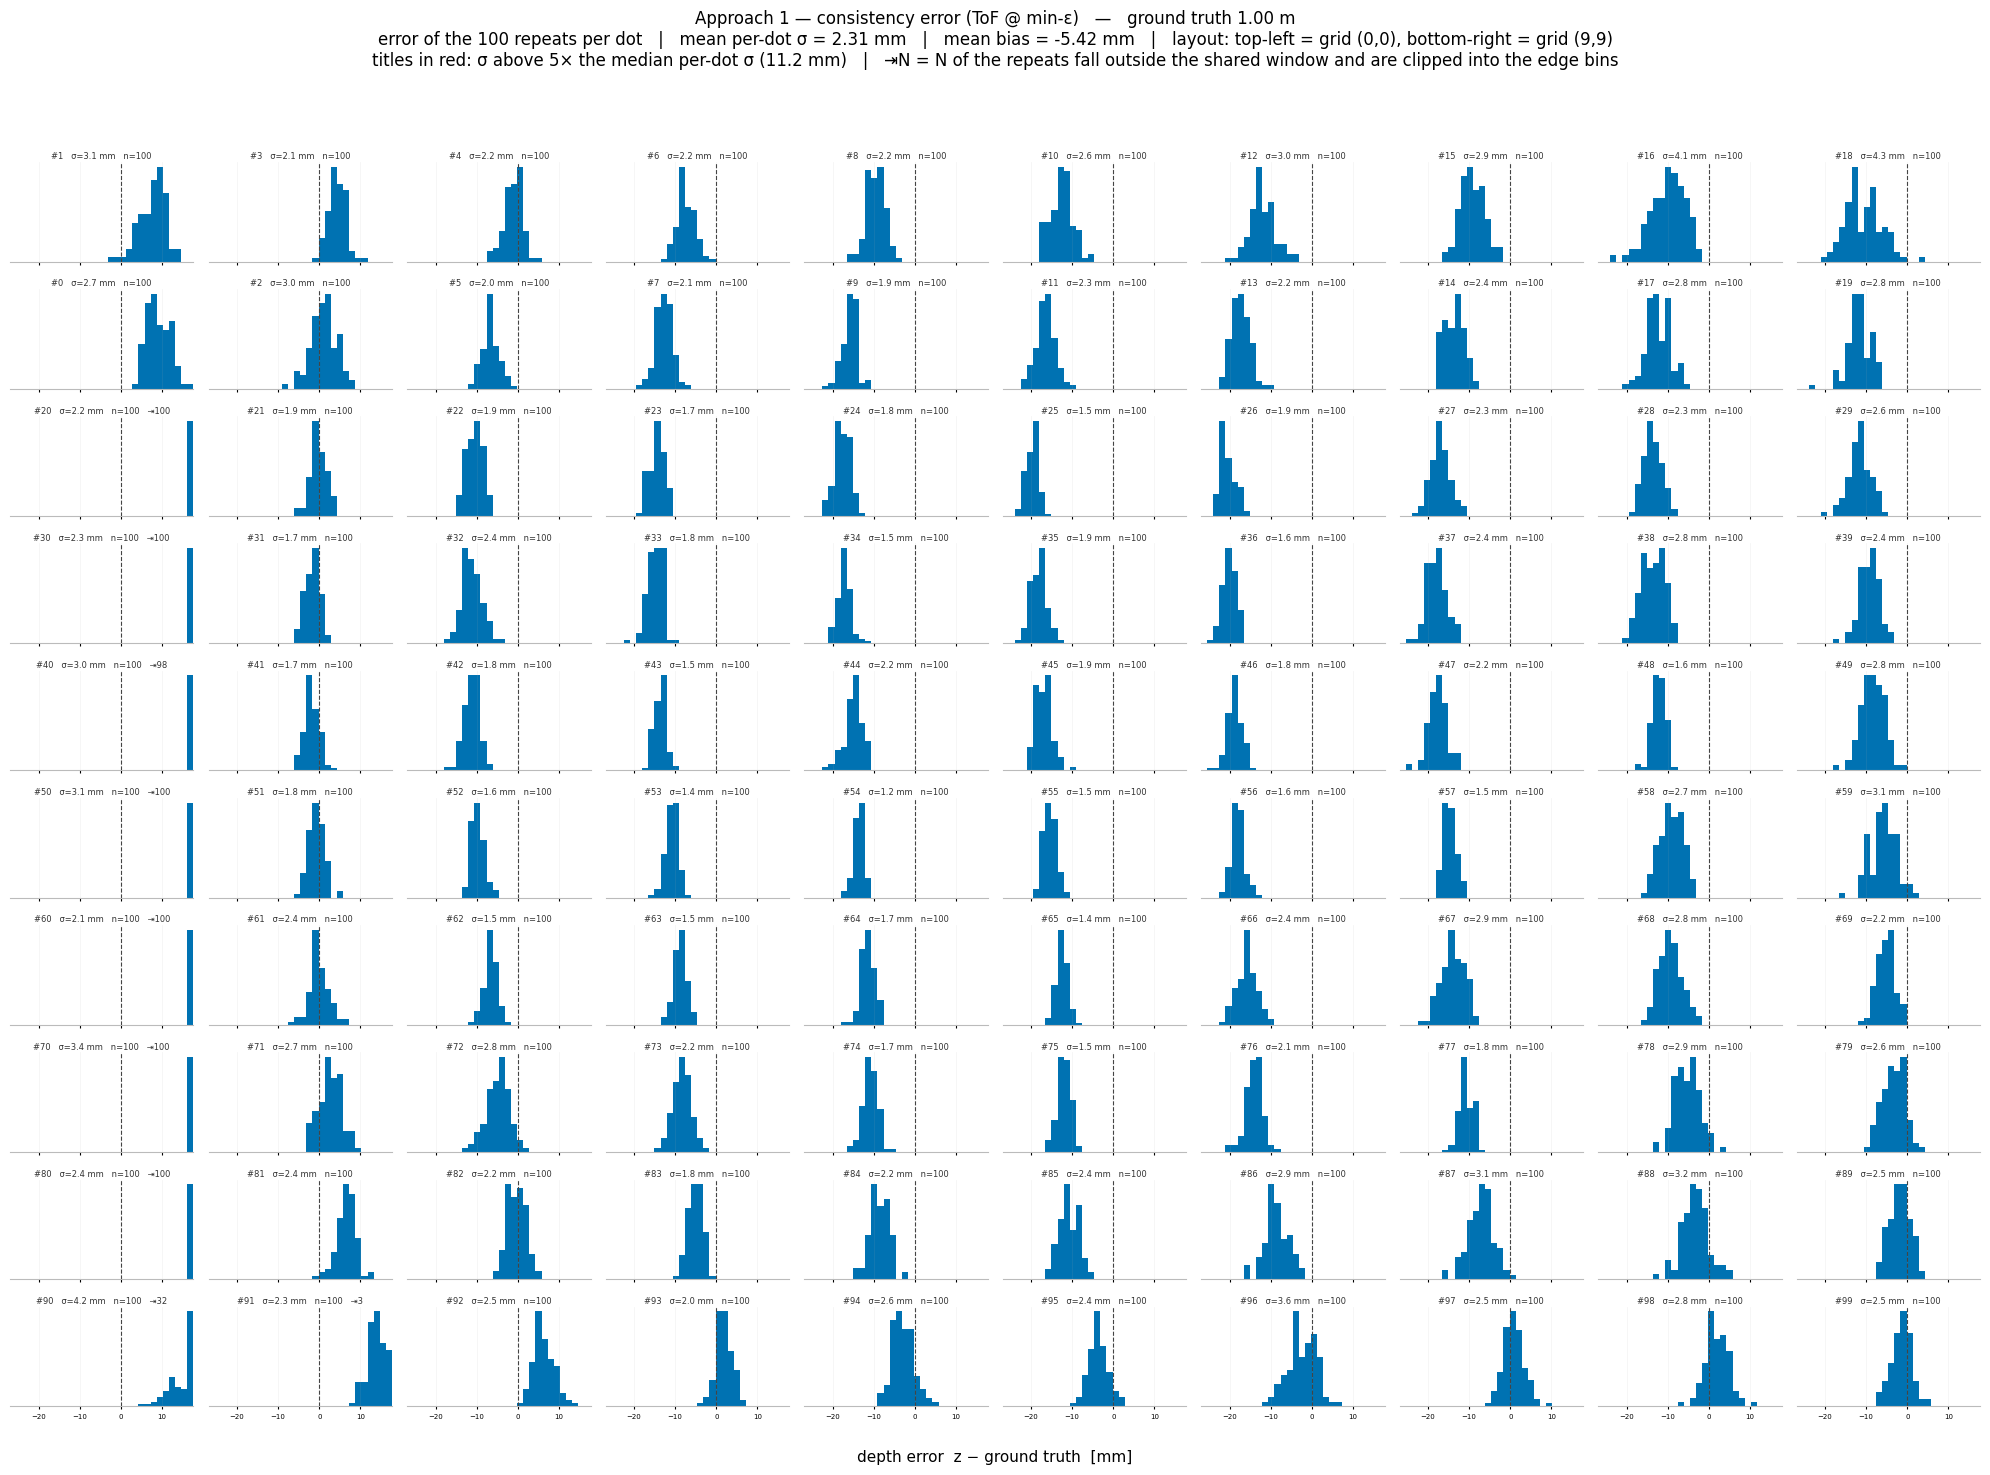

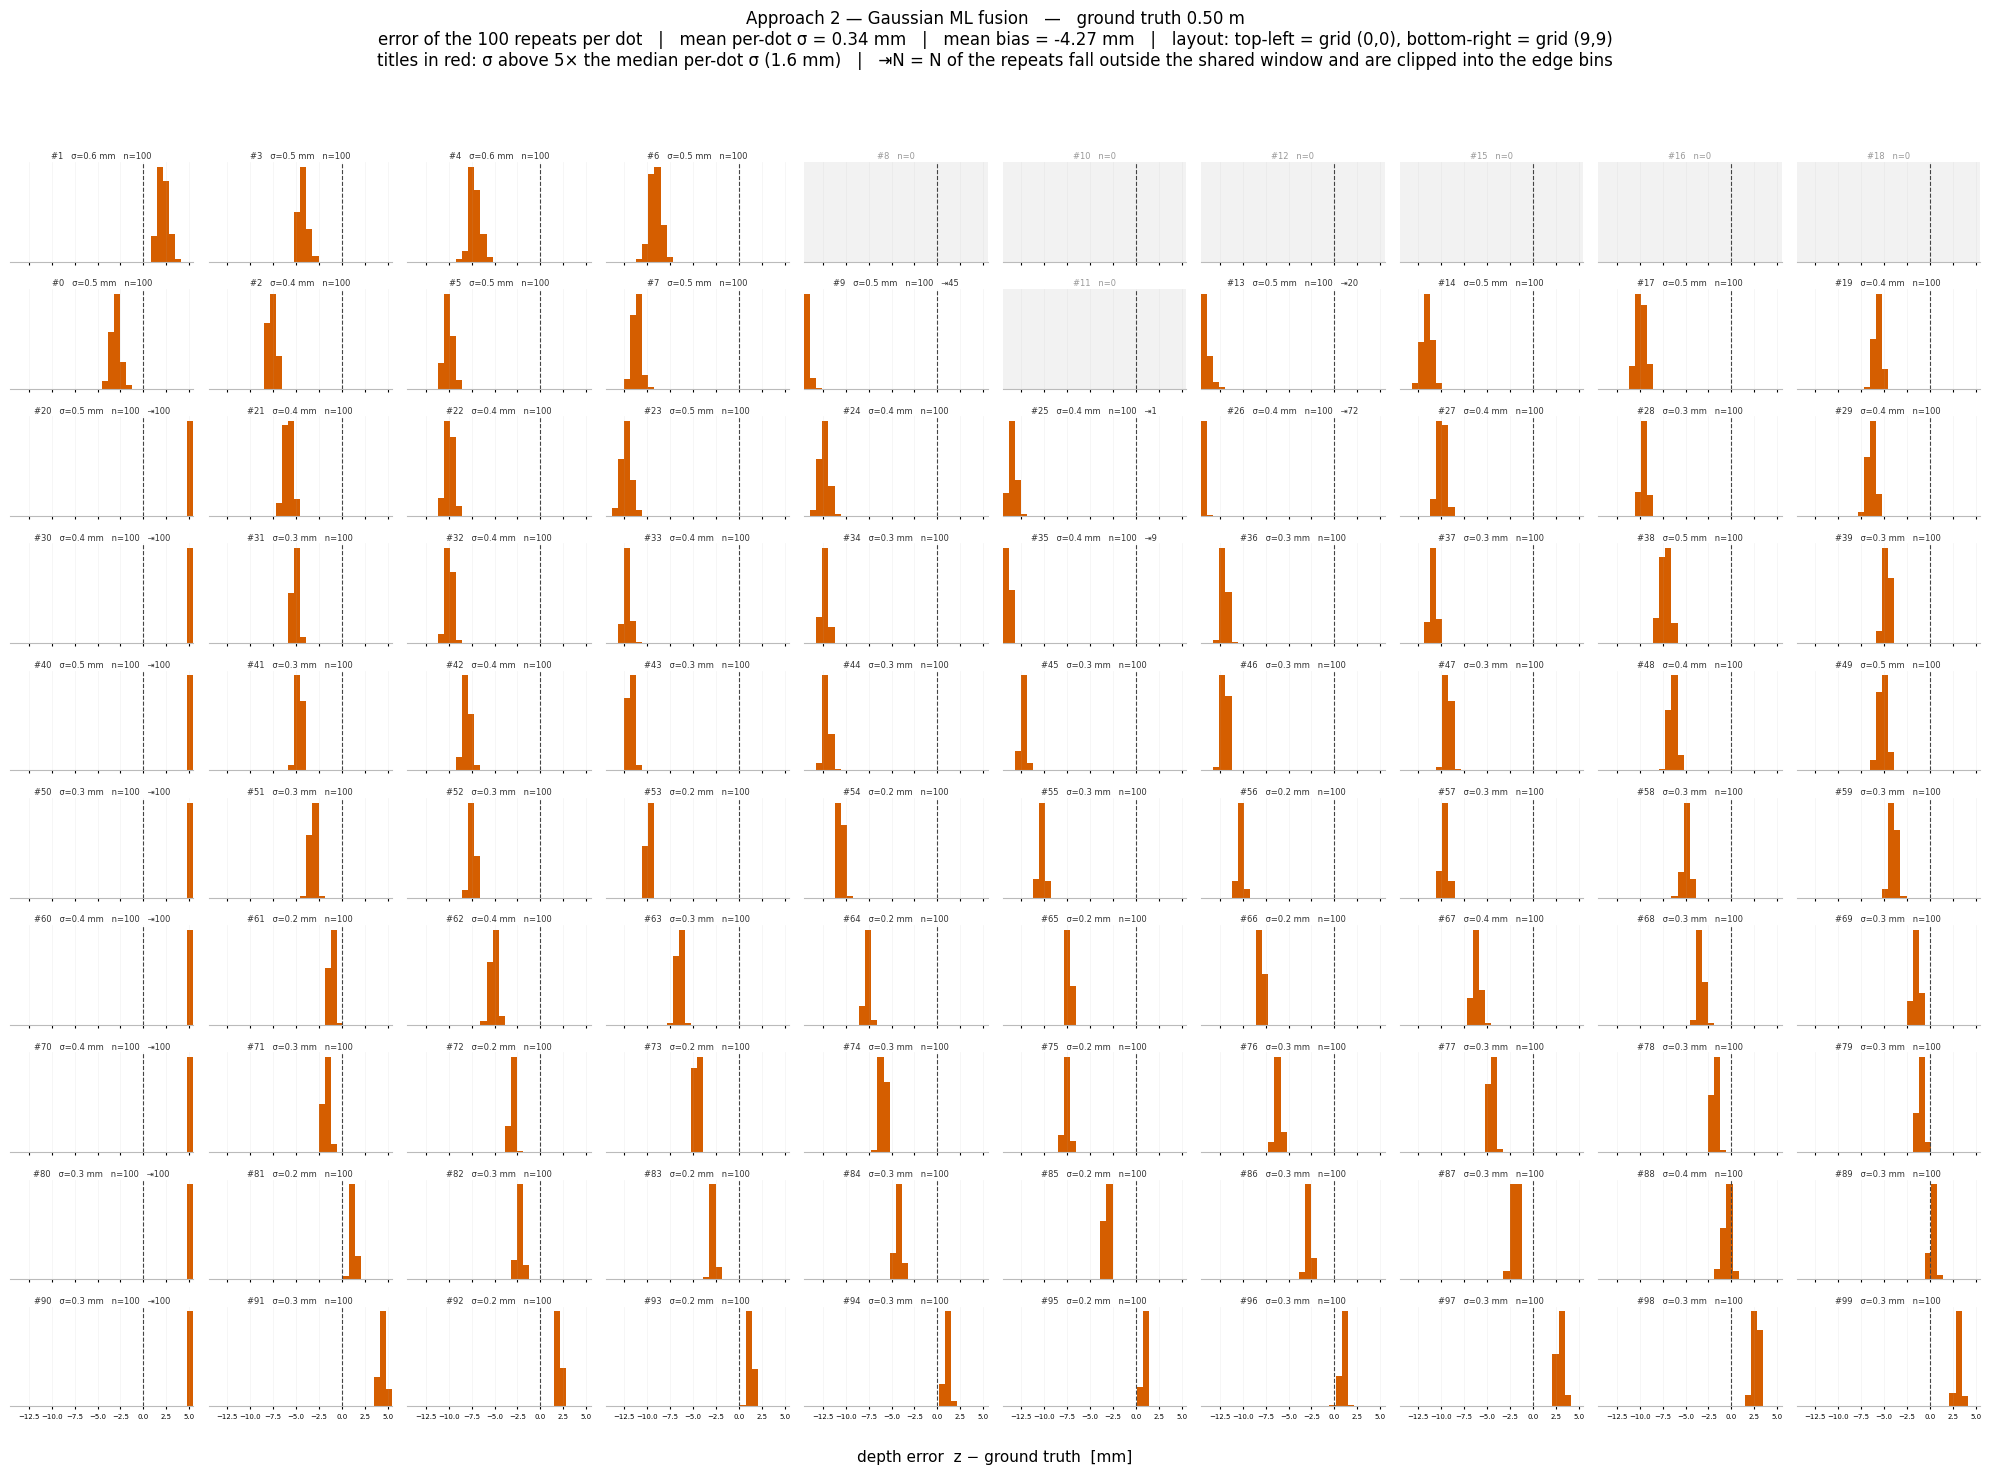

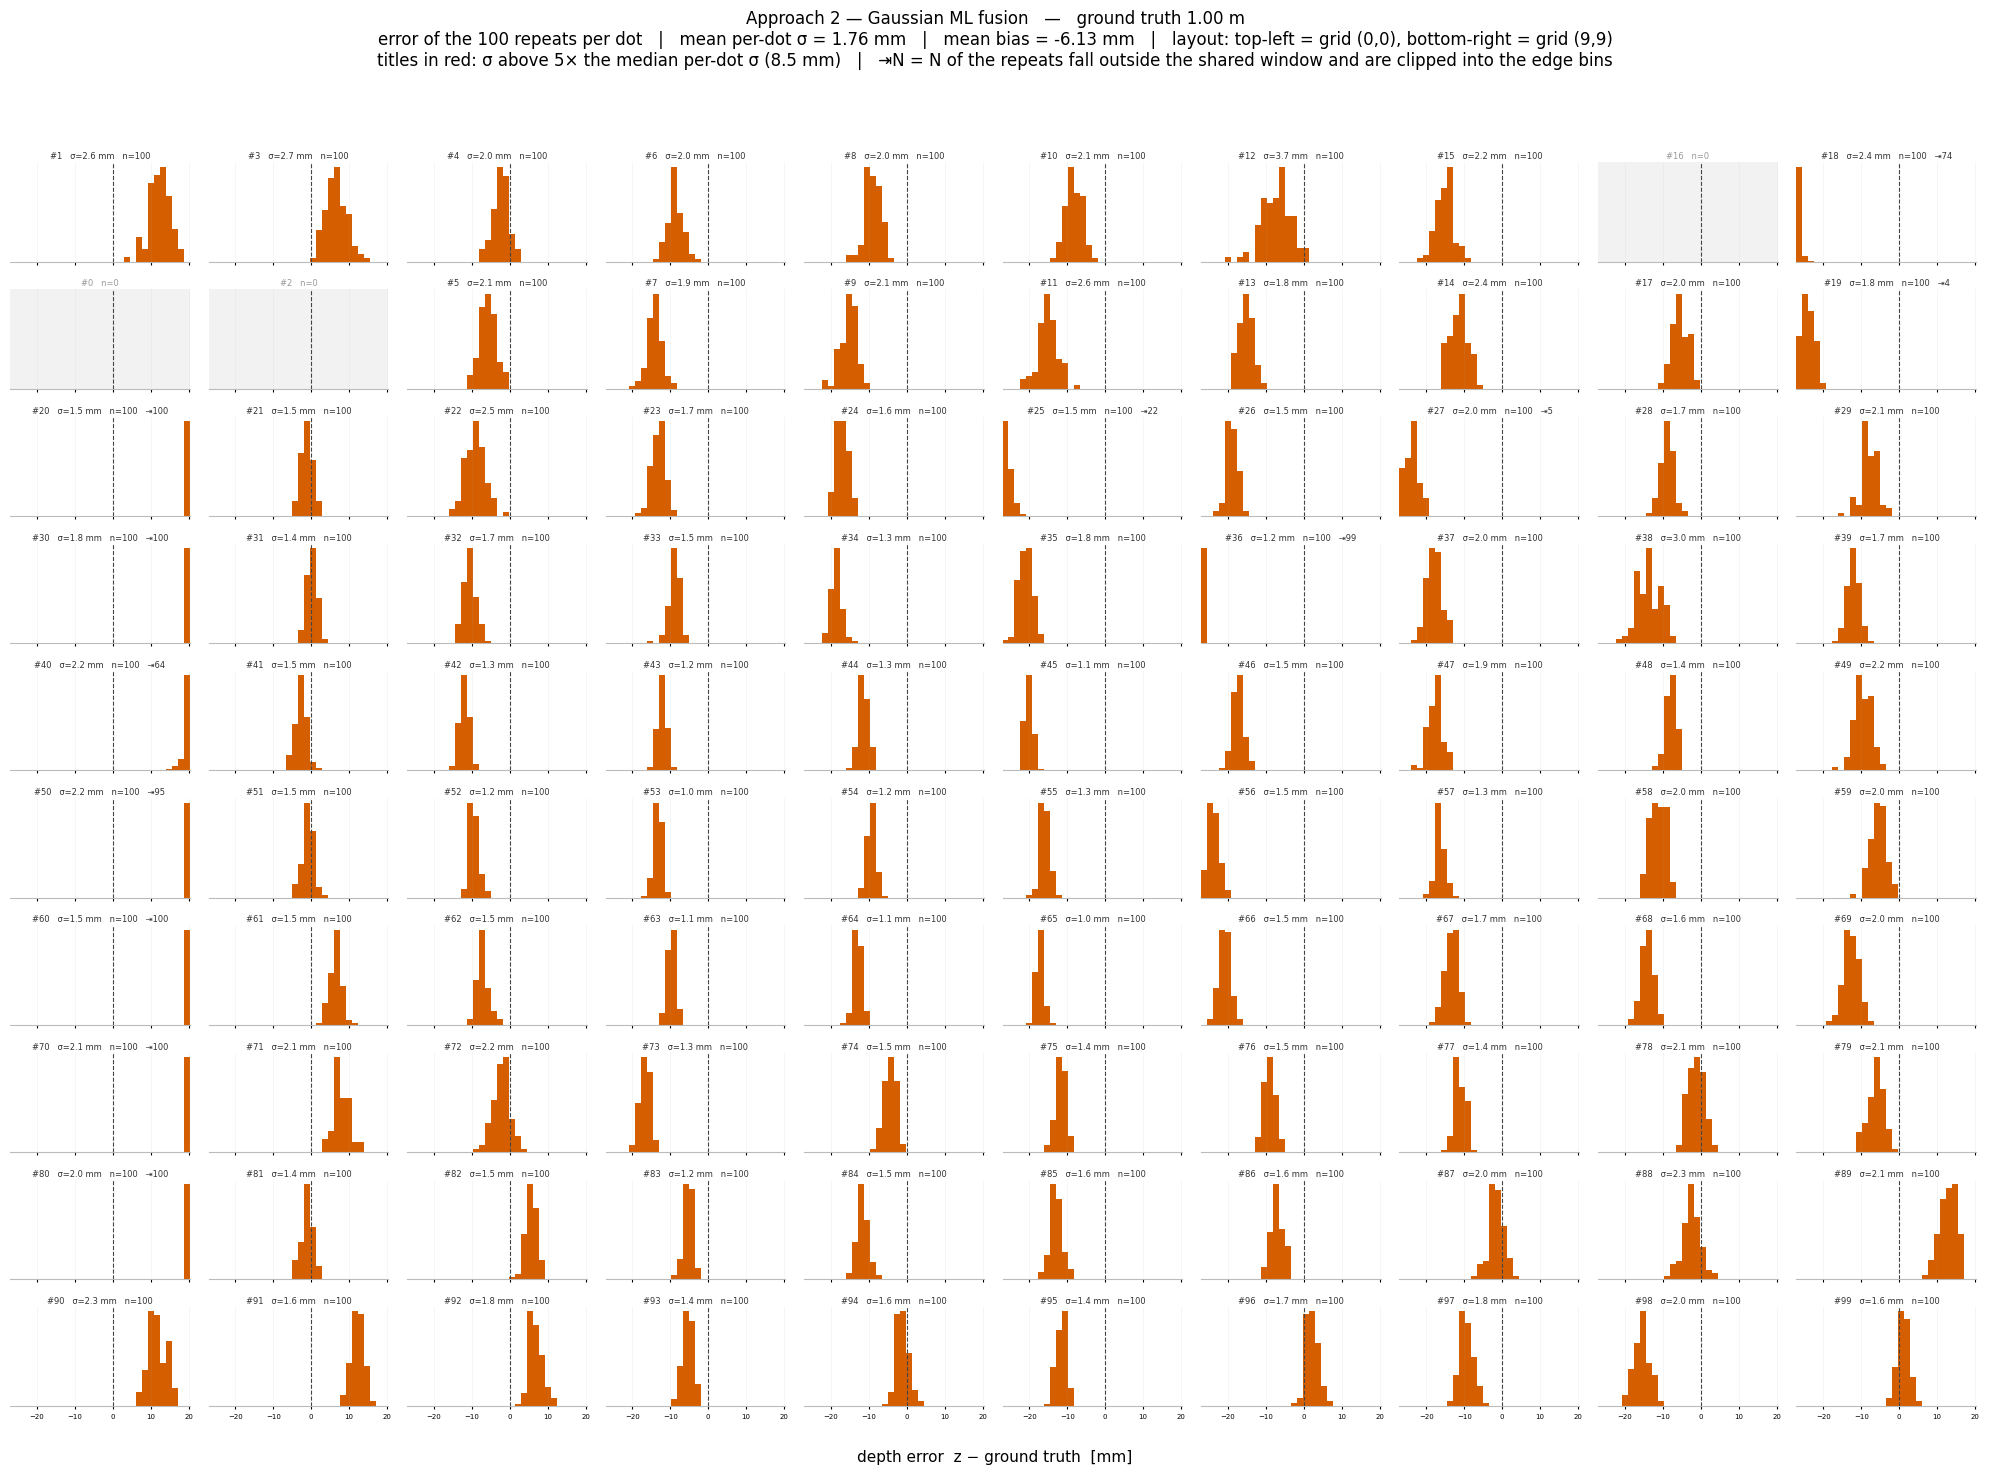

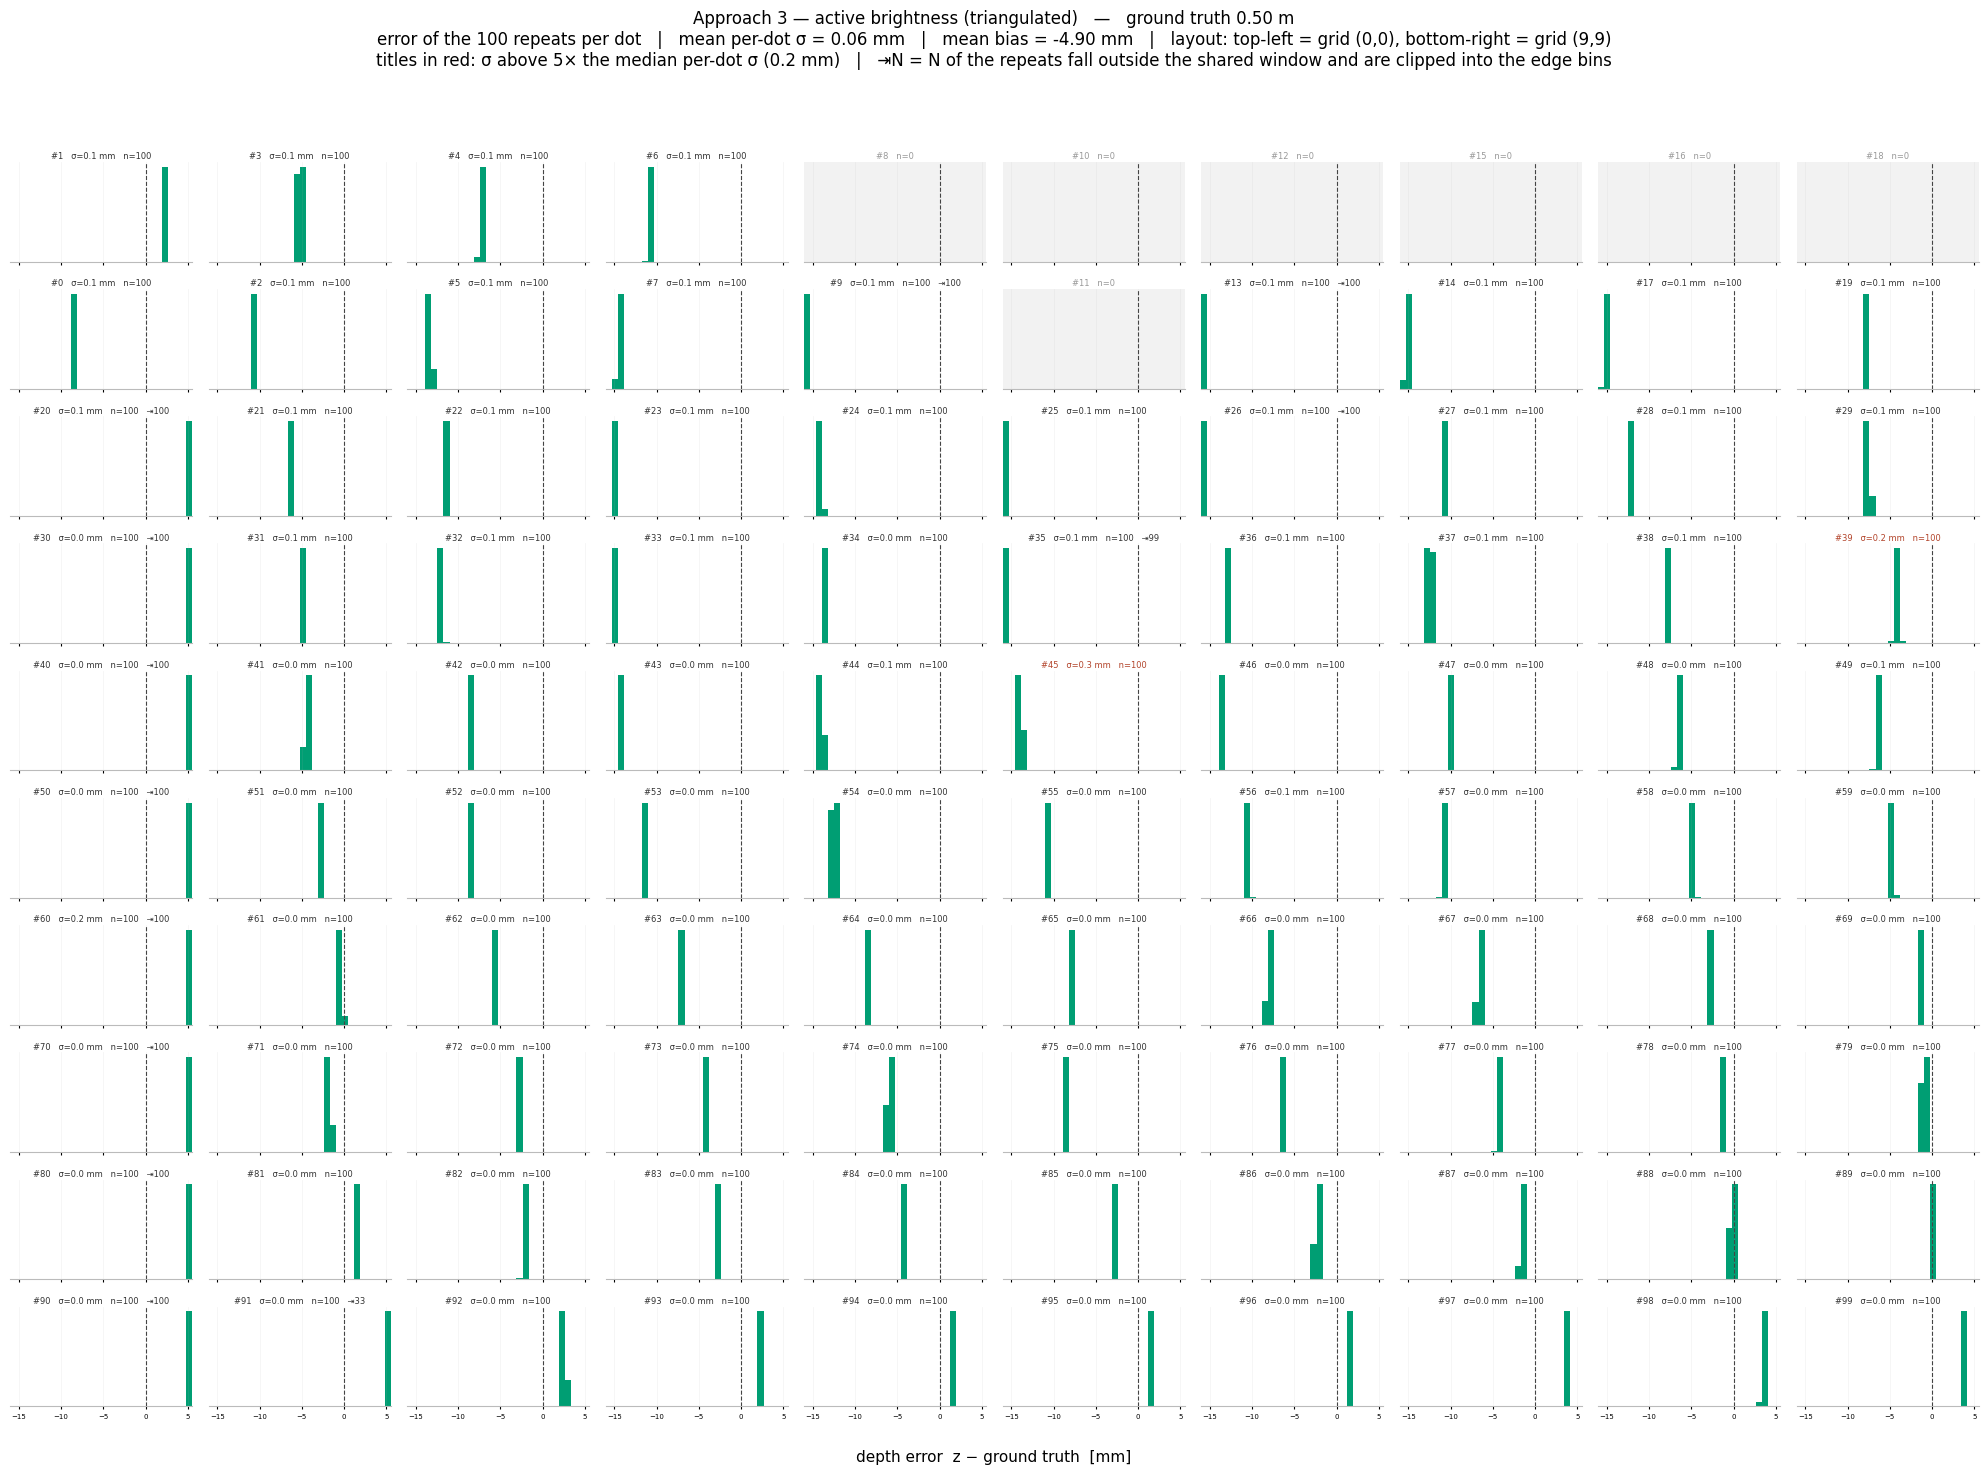

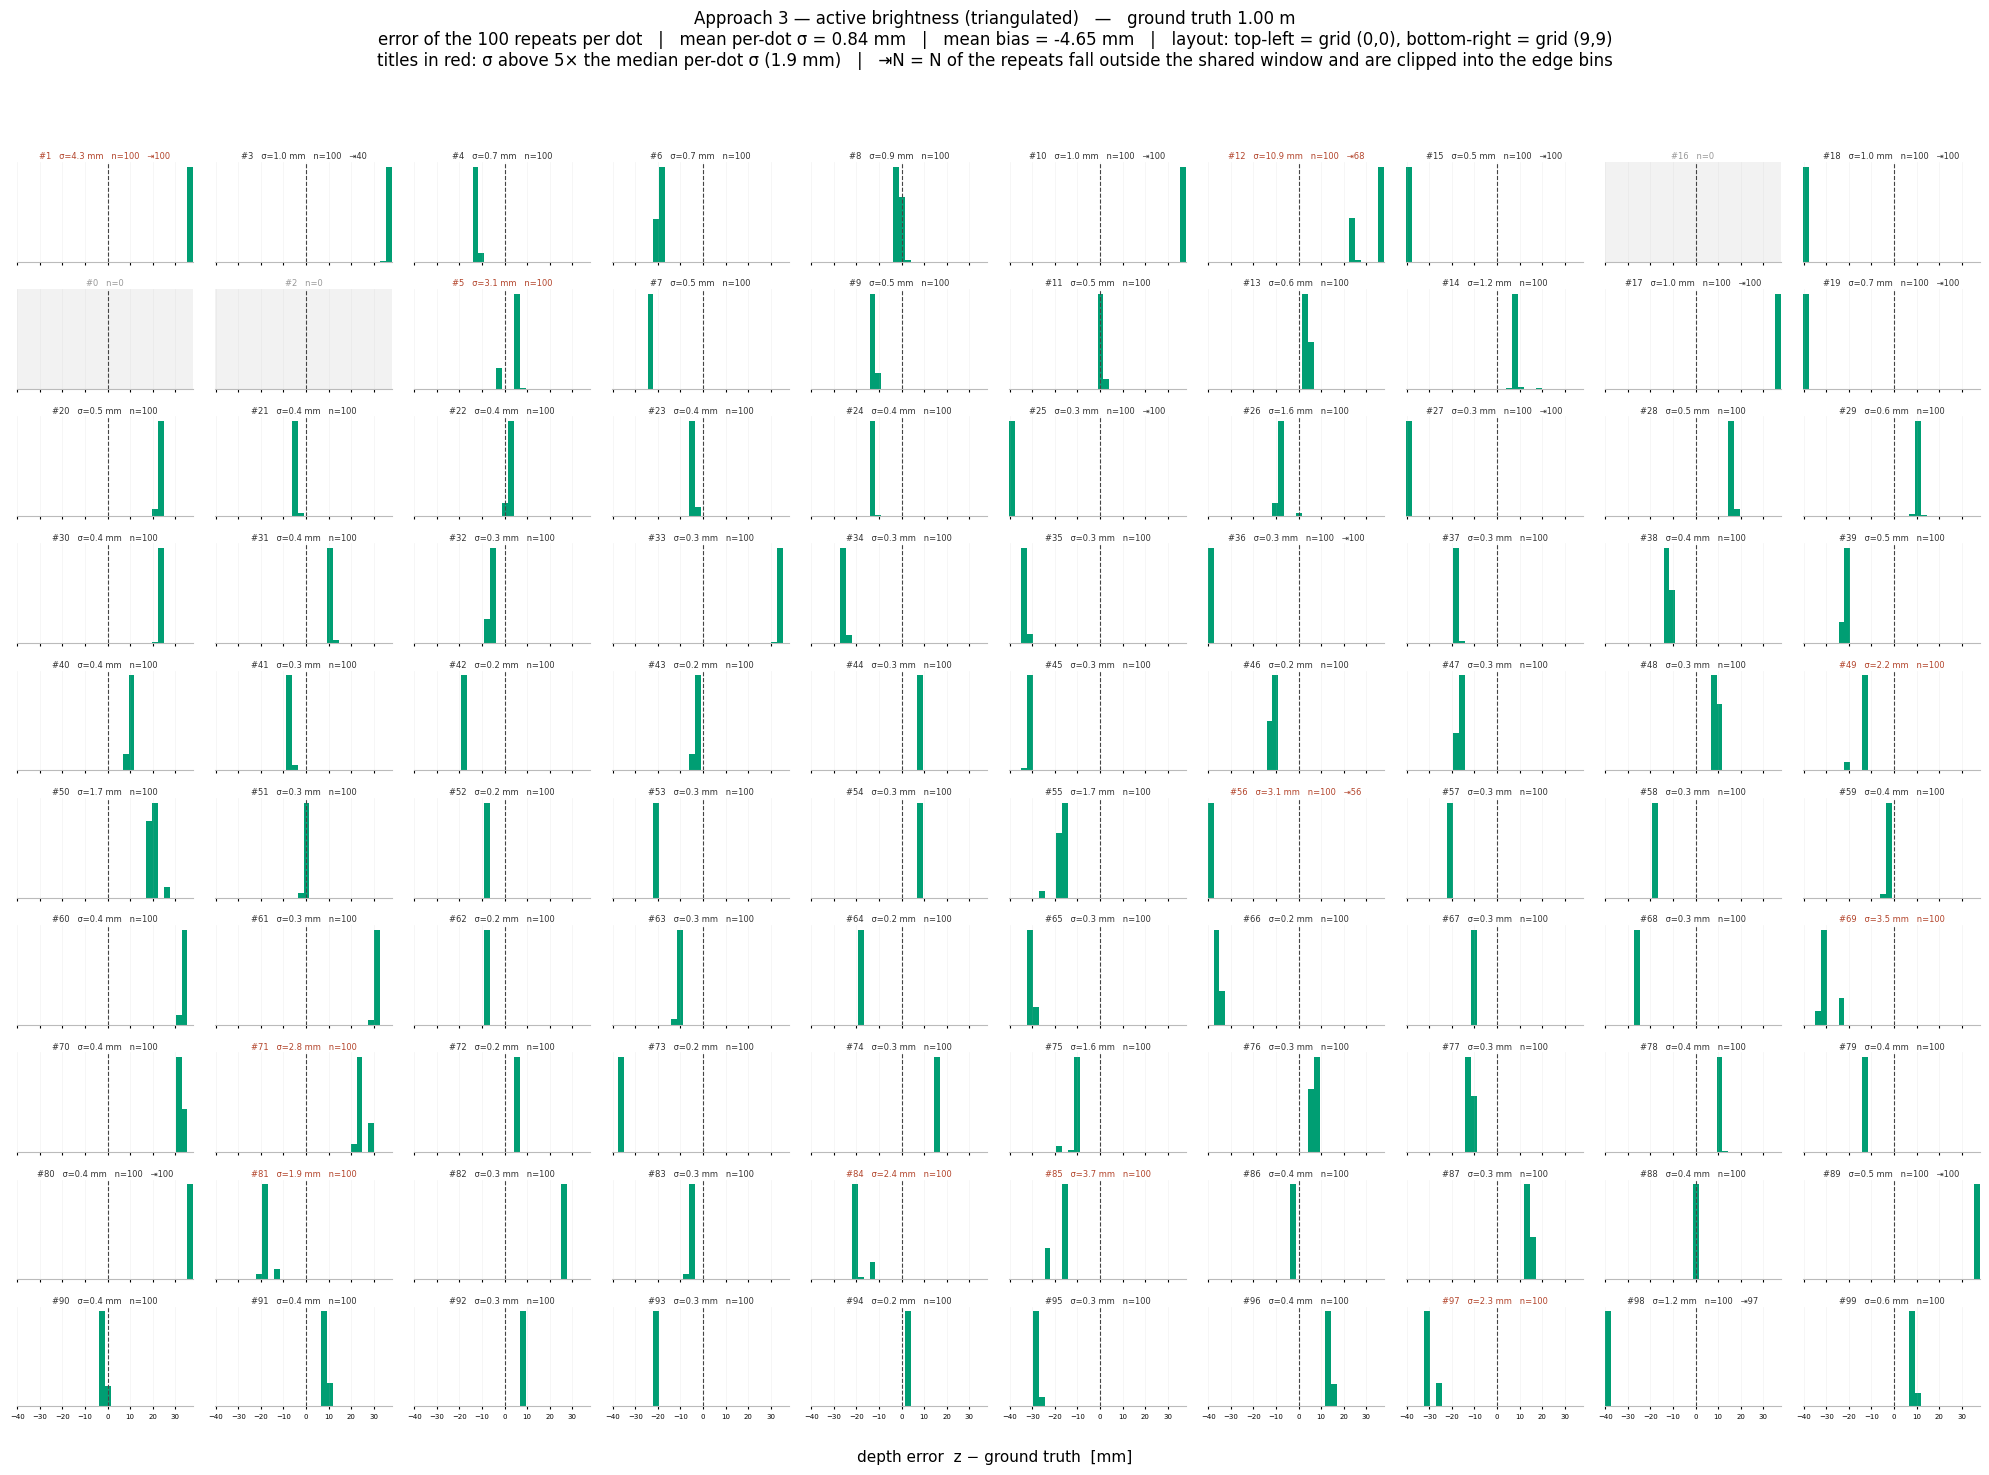

In [23]:
# ── Step E: 10×10 per-dot error distributions ────────────────────────────────
SHOW_DISTANCES  = [0.50, 1.00, 1.50, 2.00]   # ← pick freely; nearest measured is used
SHOW_APPROACHES = [1, 2, 3]                  # ← 1/2/3, or 4 = iToF-only, 5 = SL-only


def plot_dot_grid(series_idx, dist_idx, xlim=None, bins=30):
    """One panel per dot, laid out like the projected pattern: histogram of the
    100 repeats' error against ground truth. Shared x-axis across all cells."""
    gt = float(dists[dist_idx])
    err = (Zv[series_idx, dist_idx] - gt) * 1e3          # (repeats, dots) [mm]
    if not np.any(np.isfinite(err)):
        print(f"no valid samples for '{SERIES[series_idx]}' at {gt:.2f} m")
        return None

    # Window from the per-dot medians, not from all samples: a handful of dots
    # can be off by half a metre, and a 1–99 percentile over the raw samples
    # would squash every well-behaved dot into a single bin. Always keeps 0
    # (= ground truth) in frame; samples outside are clipped into the edge bins
    # and counted in the panel title.
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        sd = sigma_dot[series_idx, dist_idx] * 1e3       # per-dot σ [mm]
        bd = bias_dot[series_idx, dist_idx] * 1e3        # per-dot bias [mm]
        s_med = float(np.nanmedian(sd))
        lo = min(0.0, float(np.nanpercentile(bd, 10)) - 3 * s_med)
        hi = max(0.0, float(np.nanpercentile(bd, 90)) + 3 * s_med)
    if xlim is None:
        if not np.isfinite(lo) or not np.isfinite(hi) or hi - lo < 1e-6:
            lo, hi = -1.0, 1.0
        pad = max(0.08 * (hi - lo), 0.05)
        xlim = (lo - pad, hi + pad)
    edges = np.linspace(xlim[0], xlim[1], bins + 1)
    color = SERIES_COLOR[series_idx]
    outlier_cut = 5 * s_med if np.isfinite(s_med) and s_med > 0 else np.inf

    fig, axes = plt.subplots(10, 10, figsize=(20, 15), sharex=True)
    for r in range(10):
        for c in range(10):
            dot = int(grid_ids[r, c])
            ax = axes[r, c]
            v = err[:, dot]
            v = v[np.isfinite(v)]
            if v.size >= MIN_VALID:
                off = int(np.sum((v < xlim[0]) | (v > xlim[1])))
                ax.hist(np.clip(v, xlim[0], xlim[1]), bins=edges,
                        color=color, edgecolor="none")
                sv = v.std()
                label = f"#{dot}   σ={sv:.1f} mm   n={v.size}"
                if off:
                    label += f"   ⇥{off}"
                ax.set_title(label, fontsize=6, pad=2,
                             color="#B3452C" if sv > outlier_cut else "#333333")
            else:
                ax.set_facecolor("#f2f2f2")
                ax.set_title(f"#{dot}   n={v.size}", fontsize=6, pad=2, color="#999999")
            ax.axvline(0, color="#444444", linewidth=0.8, linestyle="--")
            ax.set_xlim(*xlim)
            ax.set_yticks([])
            ax.tick_params(axis="x", labelsize=5, length=2)
            ax.grid(axis="x", alpha=0.15, linewidth=0.5)
            for sp in ("top", "right", "left"):
                ax.spines[sp].set_visible(False)
            ax.spines["bottom"].set_color("#bbbbbb")

    sm = np.nanmean(sigma_dot[series_idx, dist_idx]) * 1e3
    bm = np.nanmean(bias_dot[series_idx, dist_idx]) * 1e3
    fig.suptitle(f"{SERIES[series_idx]}   —   ground truth {gt:.2f} m\n"
                 f"error of the {N_REP} repeats per dot   |   "
                 f"mean per-dot σ = {sm:.2f} mm   |   mean bias = {bm:+.2f} mm   |   "
                 f"layout: top-left = grid (0,0), bottom-right = grid (9,9)\n"
                 f"titles in red: σ above 5× the median per-dot σ ({outlier_cut:.1f} mm)   |   "
                 "⇥N = N of the repeats fall outside the shared window and are "
                 "clipped into the edge bins",
                 fontsize=12)
    fig.supxlabel("depth error  z − ground truth  [mm]", fontsize=11)
    fig.tight_layout(rect=(0, 0.01, 1, 0.945))
    return fig


# Requests outside DISTANCE_RANGE would otherwise snap to its edge and redraw the
# same figure — skip them and say so instead.
_step = float(np.median(np.diff(dists))) if len(dists) > 1 else 0.05
_wanted, _skipped = [], []
for _d in SHOW_DISTANCES:
    _di = int(np.argmin(np.abs(dists - _d)))
    if abs(dists[_di] - _d) > 0.5 * _step:
        _skipped.append(_d)
    elif _di not in _wanted:
        _wanted.append(_di)
if _skipped:
    print(f"outside the selected range ({dists.min():.2f} … {dists.max():.2f} m), skipped: "
          + ", ".join(f"{d:.2f} m" for d in _skipped))

for _s in SHOW_APPROACHES:
    for _di in _wanted:
        plot_dot_grid(_s - 1, _di)
        plt.show()

## Result 2 — noise *and* accuracy vs. distance


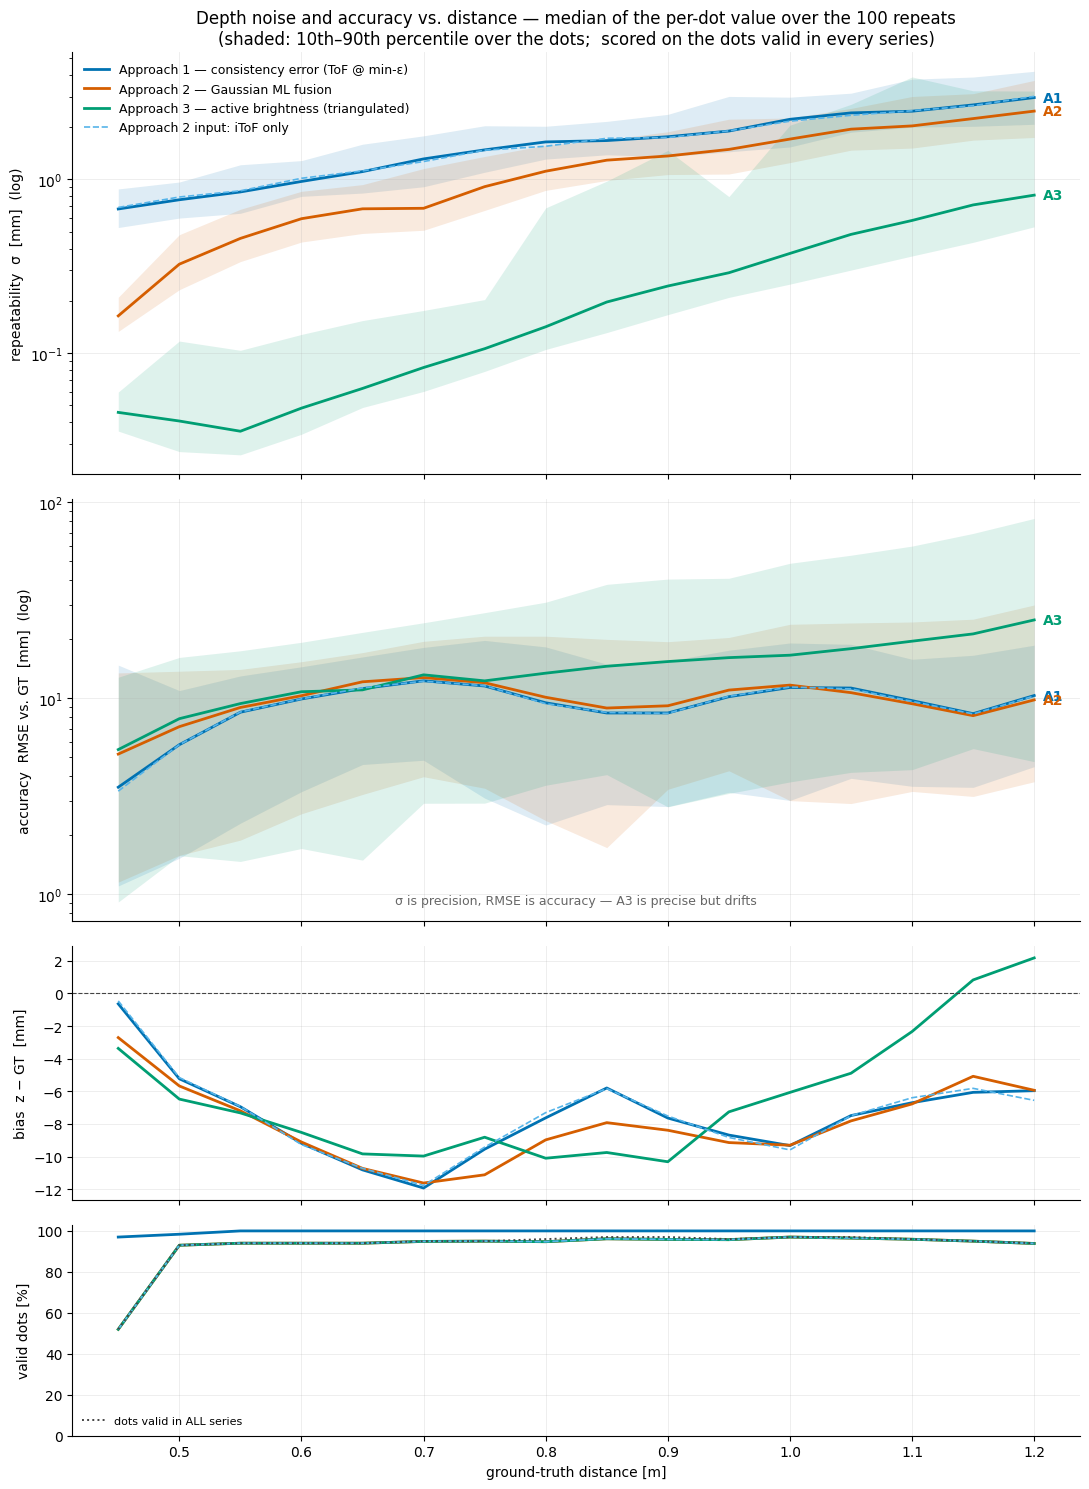

statistic: median  |  common dot set

 dist [m]  #common   σ A1 [mm]   σ A2 [mm]   σ A3 [mm]  RMSE A1 [mm]  RMSE A2 [mm]  RMSE A3 [mm]  bias A1 [mm]  bias A2 [mm]  bias A3 [mm]
     0.45       52        0.68        0.16        0.05          3.52          5.19          5.47         -0.64         -2.71         -3.37
     0.50       93        0.76        0.33        0.04          5.80          7.17          7.87         -5.23         -5.67         -6.47
     0.55       94        0.85        0.46        0.04          8.49          8.98          9.40         -6.94         -7.19         -7.32
     0.60       94        0.97        0.59        0.05          9.92         10.32         10.80         -9.18         -9.11         -8.52
     0.65       94        1.11        0.68        0.06         11.21         12.14         11.04        -10.81        -10.72         -9.83
     0.70       95        1.31        0.68        0.08         12.29         12.76         13.18        -11.93        -11.62    

In [24]:
# ── Step F: overall noise AND accuracy per distance ──────────────────────────
# Four panels on a shared distance axis — never a second y-scale on one panel.
#
# The σ panel alone is what made approach 3 look unbeatable: it is *precision*.
# The RMSE panel underneath is *accuracy*, and there the ordering is the one the
# physics predicts — triangulation (A3) wins in the near field and degrades with
# z², the iToF-based branches take over further out.
#
# Series 4 ("SL only") is by construction the same number Approach 3 returns —
# both are z_sl at the refined trail coordinate under the same ε-gate — so it is
# left out of the default plot. Add it back to confirm the two curves coincide.
SUMMARY_SERIES = [0, 1, 2, 3]

fig, axes = plt.subplots(4, 1, figsize=(11, 15), sharex=True,
                         gridspec_kw={"height_ratios": [2.0, 2.0, 1.2, 1.0]})
ax_s, ax_r, ax_b, ax_v = axes

for s in SUMMARY_SERIES:
    c, ls, lw = SERIES_COLOR[s], SERIES_STYLE[s], SERIES_LW[s]
    ax_s.plot(dists, sigma_c[s] * 1e3, ls, color=c, linewidth=lw, label=SERIES[s])
    ax_r.plot(dists, rmse_c[s] * 1e3, ls, color=c, linewidth=lw)
    if s < 3:   # spread band only for the three approaches — 5 bands is unreadable
        ax_s.fill_between(dists, sigma_p10[s] * 1e3, sigma_p90[s] * 1e3,
                          color=c, alpha=0.13, linewidth=0)
        ax_r.fill_between(dists, rmse_p10[s] * 1e3, rmse_p90[s] * 1e3,
                          color=c, alpha=0.13, linewidth=0)
    ax_b.plot(dists, bias_c[s] * 1e3, ls, color=c, linewidth=lw)
    ax_v.plot(dists, valid_frac[s] * 100, ls, color=c, linewidth=lw)

# Log scale: the approaches differ by three orders of magnitude in the range
# where they all still work — on a linear axis Approach 1 flattens the others.
ax_s.set_yscale("log")
ax_s.set_ylabel("repeatability  σ  [mm]  (log)")
ax_s.set_title(f"Depth noise and accuracy vs. distance — {STAT} of the per-dot value "
               f"over the {N_REP} repeats\n"
               f"(shaded: 10th–90th percentile over the dots;  "
               f"{'scored on the dots valid in every series' if COMMON_DOTS_ONLY else 'each series over its own valid dots'})",
               fontsize=12)
ax_s.legend(fontsize=9, frameon=False, loc="upper left")

ax_r.set_yscale("log")
ax_r.set_ylabel("accuracy  RMSE vs. GT  [mm]  (log)")
ax_r.annotate("σ is precision, RMSE is accuracy — A3 is precise but drifts",
              (0.5, 0.04), xycoords="axes fraction", ha="center",
              fontsize=9, color="#666666")

ax_b.axhline(0, color="#444444", linewidth=0.8, linestyle="--")
ax_b.set_ylabel("bias  z − GT  [mm]")

ax_v.set_ylabel("valid dots [%]")
ax_v.set_ylim(0, 103)
ax_v.set_xlabel("ground-truth distance [m]")
# How many dots every series agrees on — the population the panels above score.
ax_v.plot(dists, n_common / N_DOTS * 100, color="#444444", linewidth=1.4,
          linestyle=":", label="dots valid in ALL series")
ax_v.legend(fontsize=8, frameon=False, loc="lower left")

for ax in axes:
    ax.grid(alpha=0.25, linewidth=0.6)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

# Direct labels for the three approaches at the right edge — identity is never
# carried by colour alone.
for ax, arr in ((ax_s, sigma_c), (ax_r, rmse_c)):
    for s in (0, 1, 2):
        if s in SUMMARY_SERIES:
            y = arr[s, -1] * 1e3
            if np.isfinite(y):
                ax.annotate(f"A{s + 1}", (dists[-1], y), xytext=(6, 0),
                            textcoords="offset points", color=SERIES_COLOR[s],
                            fontsize=10, fontweight="bold", va="center")

fig.tight_layout()
plt.show()

# Table view — the same numbers, readable without colour.
print(f"statistic: {STAT}  |  "
      f"{'common dot set' if COMMON_DOTS_ONLY else 'per-series dot set'}\n")
print(f"{'dist [m]':>9}{'#common':>9}"
      + "".join(f"{'σ A%d [mm]' % (s + 1):>12}" for s in range(3))
      + "".join(f"{'RMSE A%d [mm]' % (s + 1):>14}" for s in range(3))
      + "".join(f"{'bias A%d [mm]' % (s + 1):>14}" for s in range(3)))
for di in range(N_DIST):
    print(f"{dists[di]:>9.2f}{n_common[di]:>9d}"
          + "".join(f"{sigma_c[s, di] * 1e3:>12.2f}" for s in range(3))
          + "".join(f"{rmse_c[s, di] * 1e3:>14.2f}" for s in range(3))
          + "".join(f"{bias_c[s, di] * 1e3:>+14.2f}" for s in range(3)))


## Result 3 — per-dot behaviour over distance

Which dots degrade first, and where. The heatmap gives all 100 dots × 67 distances at a glance;
the small multiples below show the same σ(distance) curve per dot, in the pattern layout.

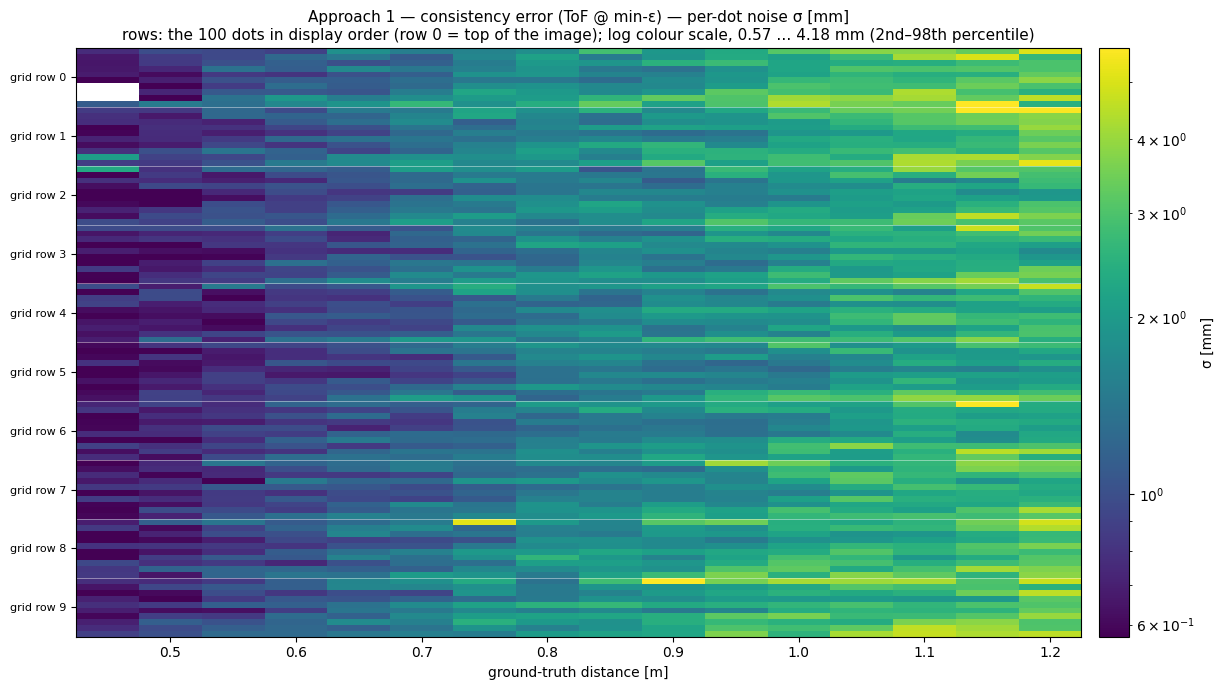

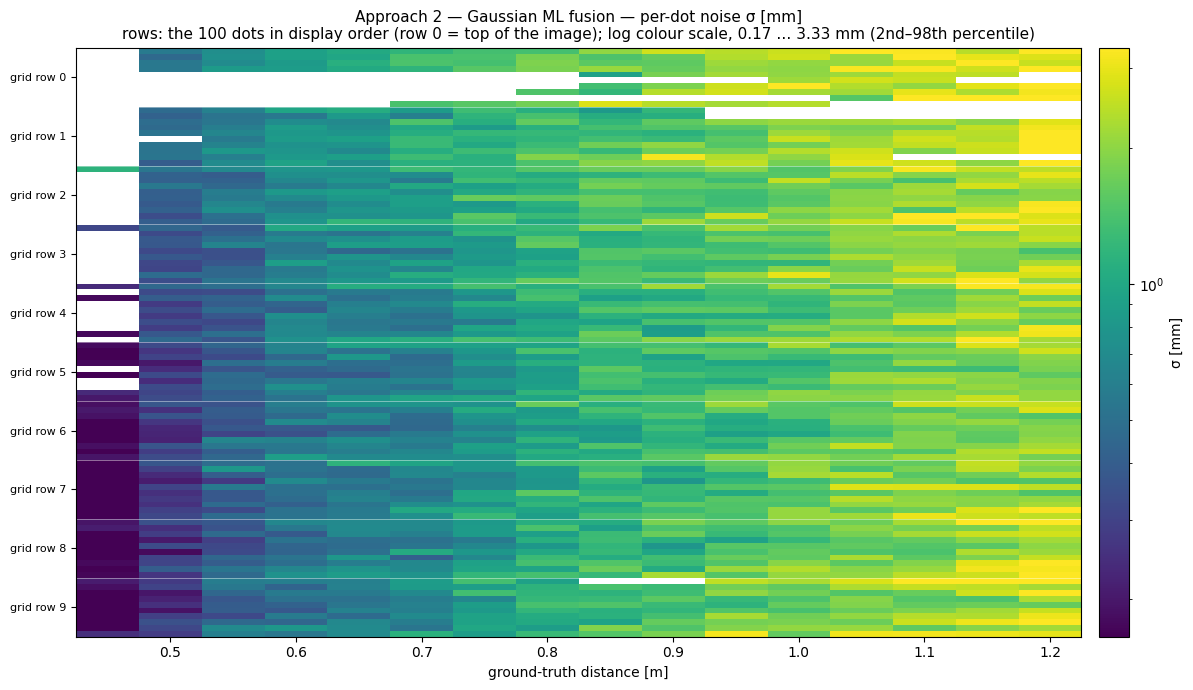

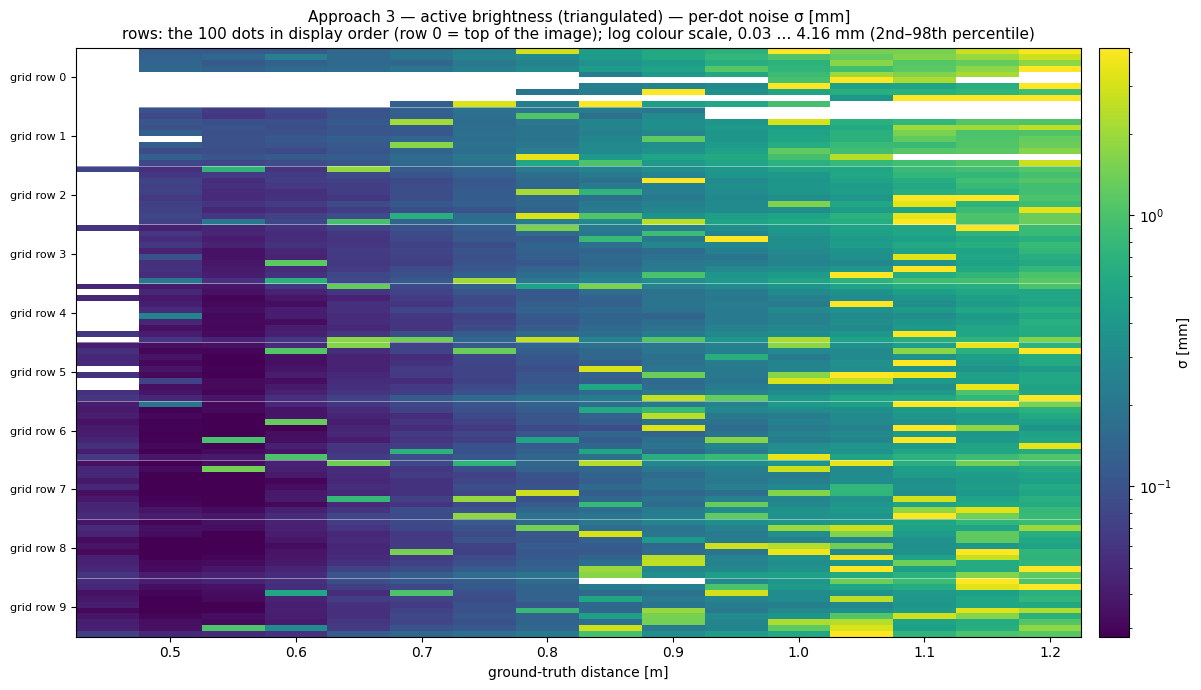

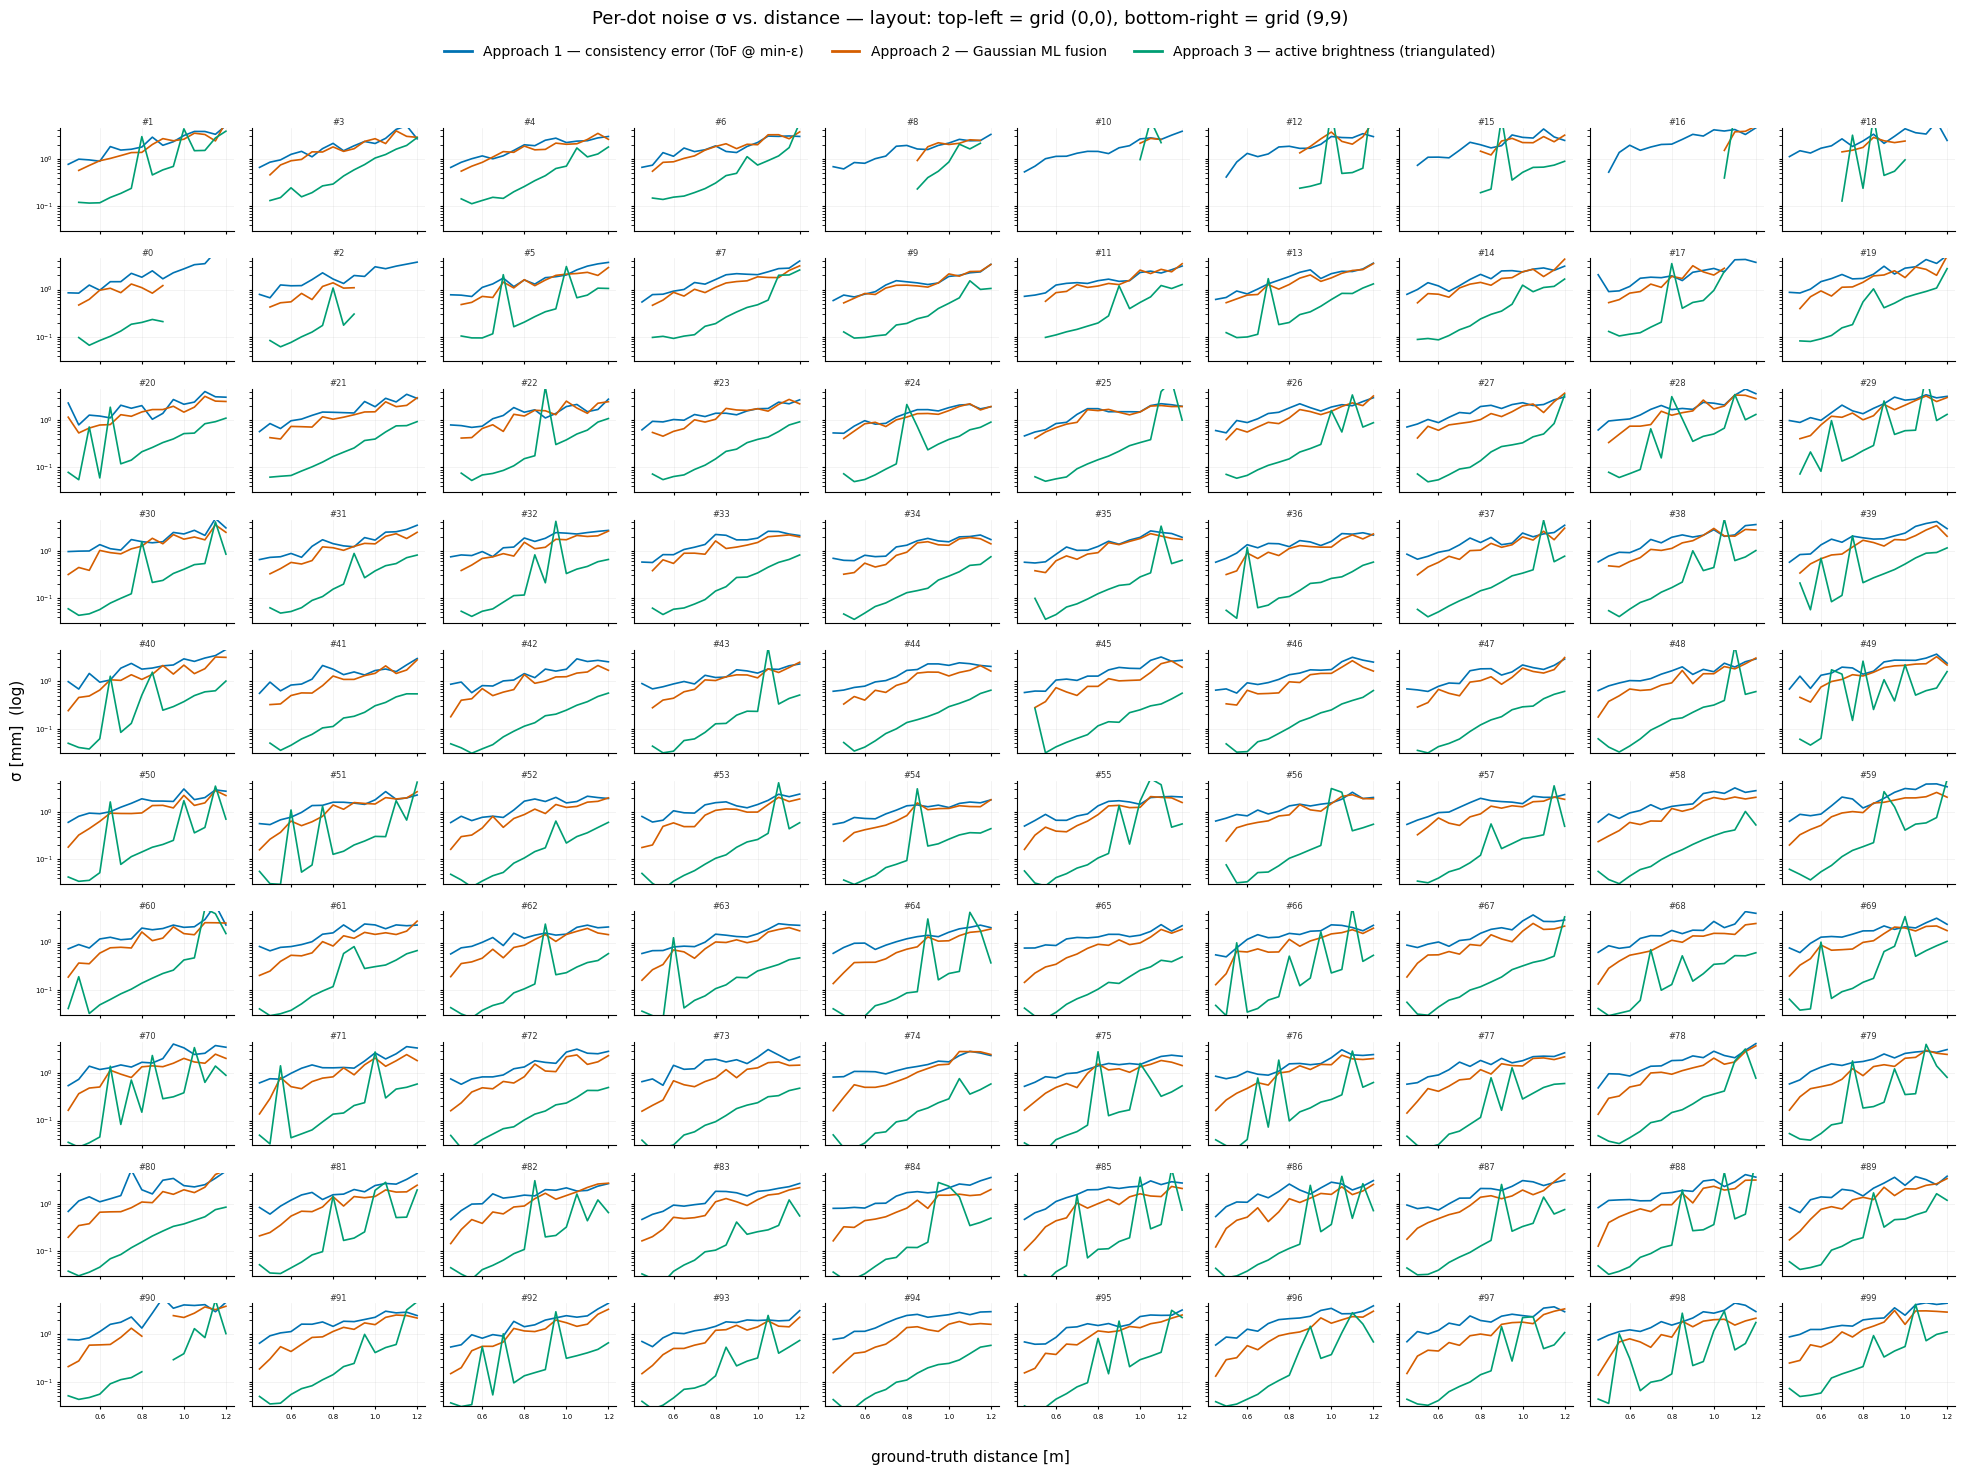

In [25]:
# ── Step G: how each individual dot behaves over distance ────────────────────
PERDOT_APPROACHES = [1, 2, 3]

import matplotlib

# (a) heatmap — rows are the 100 dots in display order, columns the distances.
#     Sequential magnitude → one perceptually uniform ramp, light → dark.
_flat = grid_ids.ravel()
for _s in PERDOT_APPROACHES:
    s = _s - 1
    M = sigma_dot[s][:, _flat].T * 1e3                      # (dots, distances) [mm]
    finite = M[np.isfinite(M)]
    vmax = float(np.percentile(finite, 98)) if finite.size else 1.0
    if not np.isfinite(vmax) or vmax <= 0:
        vmax = 1.0
    half = (dists[-1] - dists[0]) / (2 * max(len(dists) - 1, 1)) if len(dists) > 1 else 0.025

    vmin = max(float(np.percentile(finite, 2)), 1e-3) if finite.size else 1e-3
    fig, ax = plt.subplots(figsize=(13, 7))
    im = ax.imshow(M, aspect="auto", origin="upper", cmap="viridis",
                   norm=matplotlib.colors.LogNorm(vmin=vmin, vmax=max(vmax, vmin * 10)),
                   extent=(dists[0] - half, dists[-1] + half, 100, 0),
                   interpolation="nearest")
    for r in range(1, 10):
        ax.axhline(r * 10, color="white", linewidth=0.6, alpha=0.5)
    ax.set_yticks(np.arange(5, 100, 10))
    ax.set_yticklabels([f"grid row {r}" for r in range(10)], fontsize=8)
    ax.set_xlabel("ground-truth distance [m]")
    ax.set_title(f"{SERIES[s]} — per-dot noise σ [mm]\n"
                 "rows: the 100 dots in display order (row 0 = top of the image); "
                 f"log colour scale, {vmin:.2f} … {vmax:.2f} mm "
                 "(2nd–98th percentile)", fontsize=11)
    cb = fig.colorbar(im, ax=ax, pad=0.015)
    cb.set_label("σ [mm]")
    fig.tight_layout()
    plt.show()

# (b) the same data as 100 small multiples, laid out like the dot pattern.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _ymax = float(np.nanpercentile(sigma_dot[[s - 1 for s in PERDOT_APPROACHES]] * 1e3, 99))
    _ymin = float(np.nanpercentile(sigma_dot[[s - 1 for s in PERDOT_APPROACHES]] * 1e3, 1))
if not np.isfinite(_ymax) or _ymax <= 0:
    _ymax = 1.0
if not np.isfinite(_ymin) or _ymin <= 0:
    _ymin = max(_ymax * 1e-4, 1e-3)
fig, axes = plt.subplots(10, 10, figsize=(20, 15), sharex=True, sharey=True)
for r in range(10):
    for c in range(10):
        dot = int(grid_ids[r, c])
        ax = axes[r, c]
        for _s in PERDOT_APPROACHES:
            s = _s - 1
            ax.plot(dists, sigma_dot[s, :, dot] * 1e3, SERIES_STYLE[s],
                    color=SERIES_COLOR[s], linewidth=1.2)
        ax.set_title(f"#{dot}", fontsize=6, pad=2, color="#333333")
        ax.set_yscale("log")           # A1 and A3 differ by ~3 decades
        ax.set_ylim(_ymin, _ymax)
        ax.tick_params(labelsize=5, length=2)
        ax.grid(alpha=0.2, linewidth=0.5)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)

_handles = [plt.Line2D([], [], color=SERIES_COLOR[s - 1], linestyle=SERIES_STYLE[s - 1],
                       linewidth=2, label=SERIES[s - 1]) for s in PERDOT_APPROACHES]
fig.legend(handles=_handles, loc="upper center", ncol=len(_handles),
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.965))
fig.suptitle("Per-dot noise σ vs. distance — layout: top-left = grid (0,0), "
             "bottom-right = grid (9,9)", fontsize=13)
fig.supxlabel("ground-truth distance [m]", fontsize=11)
fig.supylabel("σ [mm]  (log)", fontsize=11)
fig.tight_layout(rect=(0.01, 0.01, 1, 0.94))
plt.show()

## Result 4 — why Approach 1 falls apart

Three things make the σ-only summary misleading, and this section measures the
biggest of them.

1. **σ is repeatability, not accuracy.** Approach 3 reads its depth off a
   quadratic vertex fitted to a *smoothed* brightness profile, so its random
   error is tiny while its bias grows with z² — precise, but drifting. Compare
   the RMSE panel in Result 2, where it is the worst series beyond ~0.85 m.
2. **Approach 1 is, in its core, the raw iToF depth** — `Z_out` is the ToF
   reading at the trail sample the ε-scan picked — so it cannot beat the
   "iToF only" series. Its curve sits far above the others only because a
   small fraction of dots miss completely and a *mean* over dots plots them.
3. **The misses come from the ε-gate.** ε is an inverse-depth residual with a
   constant tolerance, which in metres widens with z², and `argmin` searches
   the whole trail with no locality prior. The panels below show the p99 error
   tracking that gate width, the gross-failure rate climbing with distance, and
   the error tail landing near whole trail samples.


trail geometry: 52 samples, Δw = 0.0581 1/m per sample, gain = 16.93 px per 1/m
EPS_THRESHOLD = 0.1 1/m



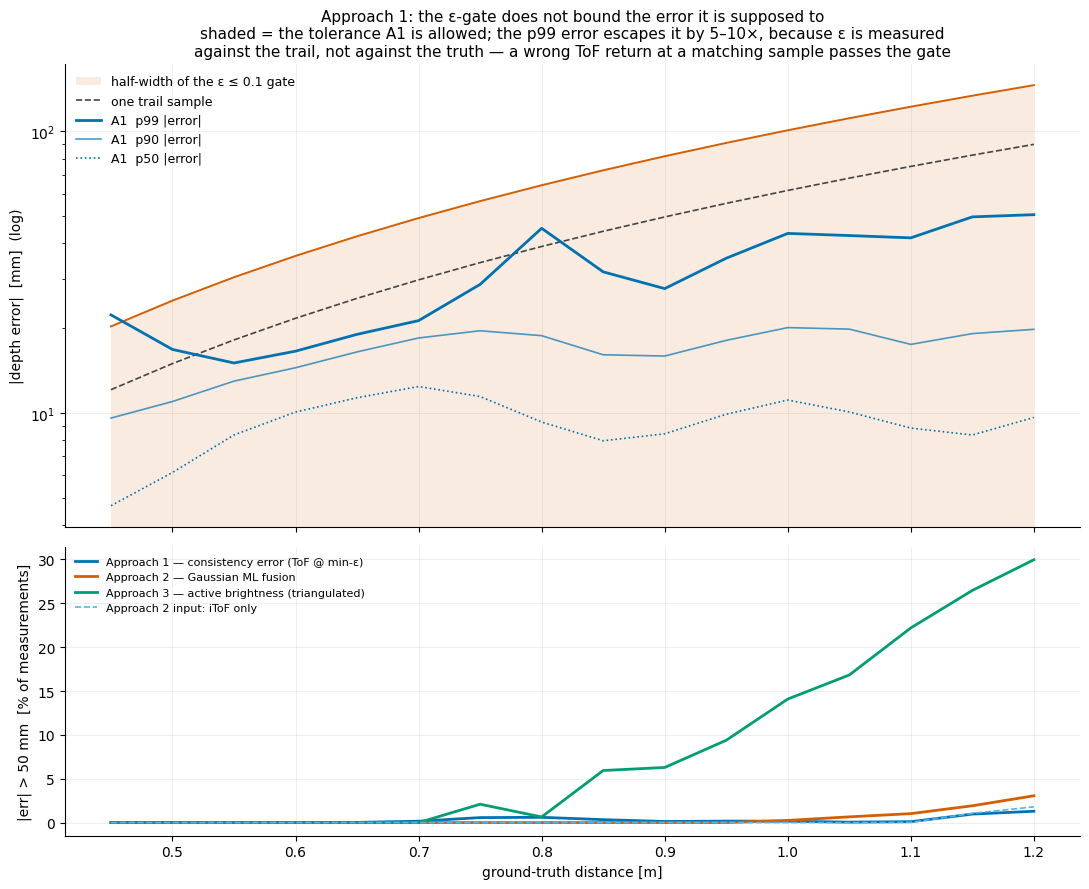

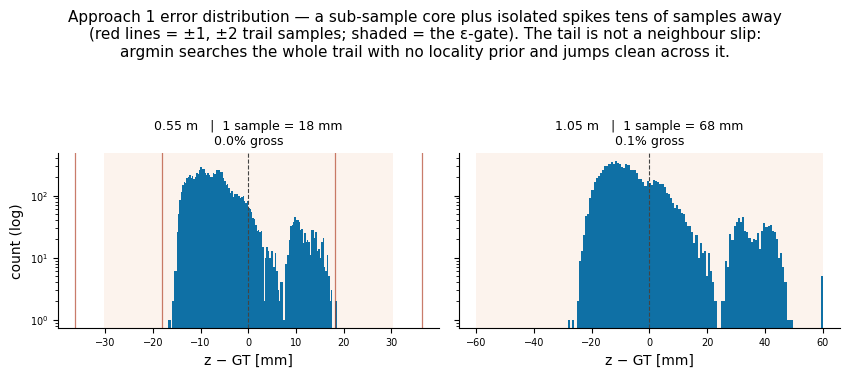

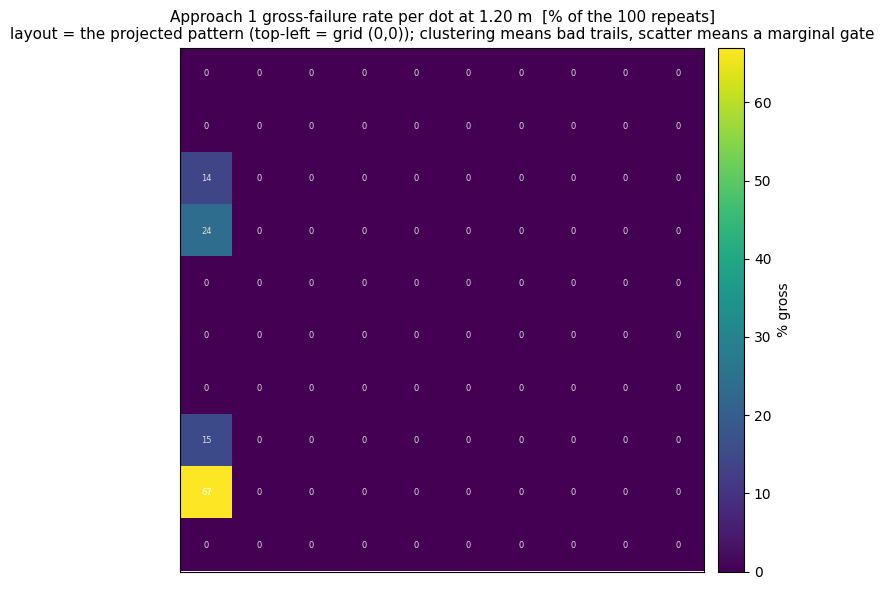

A1 gross-failure rate at 1.20 m: 1.2% overall, 4 of 100 dots affected
  per grid column:    12     0     0     0     0     0     0     0     0     0
  per grid row   :     0     0     1     2     0     0     0     2     7     0
  spread across columns   3.6 pp  vs  across rows   2.0 pp   (column >> row → the failure follows the travel axis,
  i.e. trail geometry; comparable → the gate is simply marginal everywhere)


In [44]:
# ── Step H: why Approach 1 falls apart ───────────────────────────────────────
# A1 scans the whole dot trail and keeps the sample where the ToF depth agrees
# best with the depth that sample encodes:  ε[k] = |1/Z_ToF(u_k, v_k) − w_k|,
# k_best = argmin(ε), gated by ε ≤ EPS_THRESHOLD — all in INVERSE depth.
#
# Two things go wrong, and panel (a) separates them:
#
#   * The tolerance is constant in 1/m, so in metres it grows with z²: the same
#     ε that means ±2 cm at 0.45 m means ±40 cm at 2 m. That widens the window.
#   * More importantly, ε compares the ToF reading against the TRAIL, not
#     against the truth. A spurious ToF return (multipath, a far surface, a
#     blended edge pixel) that happens to match some w_k produces a tiny ε at
#     the wrong sample, and the gate waves it through. The gate therefore does
#     NOT bound the output error — panel (a) shows A1's p99 sitting five to ten
#     times outside its own tolerance band.
#
# On top of that `argmin` searches all ~44 samples with no locality prior, and
# towards the far end w → 0 makes ε ≈ 1/Z_ToF small for *any* distant return.
A1_HIST_DISTANCES = [0.55, 1.05, 1.45, 1.85]   # ← nearest measured is used
A1_MAP_DISTANCE   = 1.55                        # distance for the per-dot map

# Read the geometry from the pipeline itself rather than hard-coding it.
EPS_THR = approaches.EPS_THRESHOLD
_trail_lens = [len(t["u"]) for t in trails if t is not None] if "trails" in dir() else []
if _trail_lens:
    _t = next(t for t in trails if t is not None)
    _dw = float(abs(_t["w"][0] - _t["w"][-1]) / max(len(_t["w"]) - 1, 1))
    _gain = float(np.hypot(_t["u"][0] - _t["u"][-1], _t["v"][0] - _t["v"][-1])
                  / max(abs(_t["w"][0] - _t["w"][-1]), 1e-9))
    print(f"trail geometry: {int(np.median(_trail_lens))} samples, "
          f"Δw = {_dw:.4f} 1/m per sample, gain = {_gain:.2f} px per 1/m")
else:   # fresh kernel that only ran the sweep-side cells
    _dw, _gain = 0.0581, 16.93
    print(f"trail geometry unavailable (calibration cells not run) — "
          f"using Δw = {_dw} 1/m, gain = {_gain} px per 1/m")
print(f"EPS_THRESHOLD = {EPS_THR} 1/m\n")


def _depth_band(z, eps=EPS_THR):
    """The metric depth window an inverse-depth tolerance `eps` accepts at z."""
    w = 1.0 / z
    return 1.0 / (w + eps), np.where(w - eps > 1e-9, 1.0 / np.maximum(w - eps, 1e-9), np.inf)


def _sample_step(z, dw=None):
    """How much depth one trail sample is worth at z [m]."""
    dw = _dw if dw is None else dw
    return np.abs(1.0 / np.maximum(1.0 / z - dw, 1e-9) - z)


# ── (a) the ε-gate width against A1's actual error tail ─────────────────────
_lo, _hi = _depth_band(dists)
_halfband = (np.minimum(_hi, 1e3) - _lo) / 2.0
_abs_err = np.abs(err[0])                                    # (D, rep, dot)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _p50 = np.nanpercentile(_abs_err, 50, axis=(1, 2))
    _p90 = np.nanpercentile(_abs_err, 90, axis=(1, 2))
    _p99 = np.nanpercentile(_abs_err, 99, axis=(1, 2))

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={"height_ratios": [1.6, 1.0]})
ax, ax2 = axes
ax.fill_between(dists, 0, _halfband * 1e3, color="#D55E00", alpha=0.12, linewidth=0,
                label=f"half-width of the ε ≤ {EPS_THR} gate")
ax.plot(dists, _halfband * 1e3, color="#D55E00", linewidth=1.4)
ax.plot(dists, _sample_step(dists) * 1e3, color="#444444", linewidth=1.2,
        linestyle="--", label="one trail sample")
ax.plot(dists, _p99 * 1e3, color="#0072B2", linewidth=2.0, label="A1  p99 |error|")
ax.plot(dists, _p90 * 1e3, color="#0072B2", linewidth=1.2, alpha=0.7, label="A1  p90 |error|")
ax.plot(dists, _p50 * 1e3, color="#0072B2", linewidth=1.2, linestyle=":", label="A1  p50 |error|")
ax.set_yscale("log")
ax.set_ylabel("|depth error|  [mm]  (log)")
ax.set_title("Approach 1: the ε-gate does not bound the error it is supposed to\n"
             "shaded = the tolerance A1 is allowed; the p99 error escapes it by "
             "5–10×, because ε is measured\nagainst the trail, not against the "
             "truth — a wrong ToF return at a matching sample passes the gate",
             fontsize=11)
ax.legend(fontsize=9, frameon=False, loc="upper left")

# ── (b) gross-failure rate per series ───────────────────────────────────────
for s in (0, 1, 2, 3):
    ax2.plot(dists, gross_c[s] * 100, SERIES_STYLE[s], color=SERIES_COLOR[s],
             linewidth=SERIES_LW[s], label=SERIES[s])
ax2.set_ylabel(f"|err| > {GROSS_MM:.0f} mm  [% of measurements]")
ax2.set_xlabel("ground-truth distance [m]")
ax2.legend(fontsize=8, frameon=False, loc="upper left")
for a in axes:
    a.grid(alpha=0.25, linewidth=0.6)
    for sp in ("top", "right"):
        a.spines[sp].set_visible(False)
fig.tight_layout()
plt.show()

# ── (c) A1's error distribution: narrow core + trail-spaced tail ────────────
_step = float(np.median(np.diff(dists))) if len(dists) > 1 else 0.05
_dsel = []
for _d in A1_HIST_DISTANCES:
    _di = int(np.argmin(np.abs(dists - _d)))
    if abs(dists[_di] - _d) <= 0.5 * _step and _di not in _dsel:
        _dsel.append(_di)

if _dsel:
    fig, axs = plt.subplots(1, len(_dsel), figsize=(4.3 * len(_dsel), 3.8), sharey=True)
    axs = np.atleast_1d(axs)
    for ax, di in zip(axs, _dsel):
        e = err[0, di].ravel() * 1e3
        e = e[np.isfinite(e)]
        lim = max(np.percentile(np.abs(e), 99.5), 60.0)
        ax.hist(np.clip(e, -lim, lim), bins=120, color=SERIES_COLOR[0], edgecolor="none")
        ax.set_yscale("log")
        ax.axvline(0, color="#444444", linewidth=0.8, linestyle="--")
        st = _sample_step(dists[di]) * 1e3
        for m in (1, 2):
            for sgn in (-1, 1):
                if abs(sgn * m * st) <= lim:
                    ax.axvline(sgn * m * st, color="#B3452C", linewidth=0.9, alpha=0.7)
        gate = _halfband[di] * 1e3
        ax.axvspan(-min(gate, lim), min(gate, lim), color="#D55E00", alpha=0.07, linewidth=0)
        ax.set_title(f"{dists[di]:.2f} m   |  1 sample = {st:.0f} mm\n"
                     f"{np.mean(np.abs(e) > GROSS_MM):.1%} gross", fontsize=9)
        ax.set_xlabel("z − GT [mm]")
        ax.tick_params(labelsize=7)
        for sp in ("top", "right"):
            ax.spines[sp].set_visible(False)
    axs[0].set_ylabel("count (log)")
    fig.suptitle("Approach 1 error distribution — a sub-sample core plus isolated "
                 "spikes tens of samples away\n"
                 "(red lines = ±1, ±2 trail samples; shaded = the ε-gate). The tail is "
                 "not a neighbour slip:\nargmin searches the whole trail with no "
                 "locality prior and jumps clean across it.",
                 fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    plt.show()

# ── (d) is it always the same dots? ─────────────────────────────────────────
_mi = int(np.argmin(np.abs(dists - A1_MAP_DISTANCE)))
_M = gross_dot[0, _mi][grid_ids] * 100                      # (10, 10) in display order
fig, ax = plt.subplots(figsize=(7.2, 6))
im = ax.imshow(_M, cmap="viridis", vmin=0, vmax=max(np.nanmax(_M), 1e-9),
               interpolation="nearest")
for r in range(10):
    for c in range(10):
        v = _M[r, c]
        ax.text(c, r, "—" if not np.isfinite(v) else f"{v:.0f}", ha="center", va="center",
                fontsize=6, color="white" if np.isfinite(v) and v > np.nanmax(_M) / 2 else "#dddddd")
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"Approach 1 gross-failure rate per dot at {dists[_mi]:.2f} m  "
             f"[% of the {N_REP} repeats]\n"
             "layout = the projected pattern (top-left = grid (0,0)); "
             "clustering means bad trails, scatter means a marginal gate", fontsize=11)
fig.colorbar(im, ax=ax, pad=0.02, label="% gross")
fig.tight_layout()
plt.show()

# Is the pattern structured or scattered? Report it instead of asserting it —
# a column/row structure points at the trail geometry (how much of each dot's
# trail is still inside the image), scatter points at a marginal gate.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _col = np.nanmean(_M, axis=0)
    _row = np.nanmean(_M, axis=1)
print(f"A1 gross-failure rate at {dists[_mi]:.2f} m: "
      f"{np.nanmean(gross_dot[0, _mi]):.1%} overall, "
      f"{int(np.nansum(gross_dot[0, _mi] > 0.01))} of {N_DOTS} dots affected")
print("  per grid column: " + " ".join(f"{v:5.0f}" for v in _col))
print("  per grid row   : " + " ".join(f"{v:5.0f}" for v in _row))
print(f"  spread across columns {np.nanstd(_col):5.1f} pp  vs  across rows "
      f"{np.nanstd(_row):5.1f} pp   (column >> row → the failure follows the "
      f"travel axis,\n  i.e. trail geometry; comparable → the gate is simply "
      f"marginal everywhere)")
